In [1]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point
from sklearn.impute import SimpleImputer
import scipy.stats as stats
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from pandas.plotting import parallel_coordinates

# Ensure image output directory exists and provide a helper to save figures
IMG_DIR = os.path.abspath(os.path.join('..', '..', 'Rapport_TP', 'images', 'Soil'))
os.makedirs(IMG_DIR, exist_ok=True)

def savefig(name: str, dpi: int = 200, tight: bool = True):
    """Save the current matplotlib figure into the project images folder.

    Parameters
    - name: filename or basename (extension optional). If no extension, `.png` is used.
    - dpi: image DPI
    - tight: apply tight_layout before saving
    """
    base, ext = os.path.splitext(name)
    if not ext:
        ext = '.png'
    filename = f"{base}{ext}"
    path = os.path.join(IMG_DIR, filename)

    # Apply tight layout if requested (best-effort)
    if tight:
        try:
            plt.tight_layout()
        except Exception:
            pass

    # Remove existing file (we prefer replacing)
    try:
        if os.path.exists(path):
            os.remove(path)
    except Exception:
        pass

    # Use matplotlib's savefig (not this helper) to actually write the file
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"Saved figure: {path}")


In [2]:
# loading soil dataset
df_soil = pd.read_csv('../../ExtractedDatasets/SoilFeatures/hwsd2_grid01_D1.csv')

In [3]:
df_soil.shape

(23262, 27)

In [4]:
#df_soil memory usage
print("Soil Data Memory Usage:", df_soil.memory_usage(deep=True).sum() / (1024 ** 2), "MB")

Soil Data Memory Usage: 5.9011688232421875 MB


In [5]:
df_soil.describe()

,y,x,band,spatial_ref,HWSD2_SMU_ID,COARSE,SAND,SILT,CLAY,TEXTURE_USDA,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
count,23262.000000,23262.000000,23262.0,23262.0,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,17782.000000,...,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000
mean,28.566299,3.150593,1.0,0.0,3308.185625,7.777534,39.715115,21.707678,12.355300,9.630806,...,8.509028,43.752343,25.178961,22.522913,68.225948,-0.871378,2.249678,6.534232,0.993225,0.160261
std,4.448850,4.574674,0.0,0.0,7843.976730,7.955769,26.359172,15.604824,10.159885,1.759534,...,7.841284,29.658153,21.244188,22.015838,42.064991,1.723344,7.149722,6.691281,6.634088,2.835915
min,18.991667,-8.616667,1.0,0.0,36.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,25.091667,-0.116667,1.0,0.0,193.000000,3.000000,31.000000,6.000000,6.000000,9.000000,...,5.000000,35.000000,12.000000,10.000000,64.000000,0.000000,1.000000,0.000000,0.100000,0.000000
50%,28.391667,3.483333,1.0,0.0,1645.000000,12.000000,49.000000,27.000000,16.000000,9.000000,...,13.000000,52.000000,30.000000,30.000000,97.000000,0.000000,3.000000,8.000000,0.300000,1.000000
75%,32.191667,6.783333,1.0,0.0,1833.000000,12.000000,57.000000,33.000000,18.000000,11.000000,...,14.000000,68.000000,38.000000,38.000000,100.000000,0.000000,3.000000,11.300000,0.700000,1.000000
max,37.491667,11.983333,1.0,0.0,32050.000000,46.000000,90.000000,46.000000,55.000000,12.000000,...,41.000000,83.000000,143.000000,143.000000,100.000000,40.000000,67.000000,27.900000,57.599998,32.000000


In [6]:
df_soil.columns

Index(['y', 'x', 'band', 'spatial_ref', 'HWSD2_SMU_ID', 'COARSE', 'SAND',
       'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK',
       'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY',
       'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM',
       'ELEC_COND'],
      dtype='object')

In [7]:
#columns values and counts

for col in ["band","spatial_ref","PH_WATER"]:
    print("Column:", col)
    print(df_soil[col].value_counts())
    print("\n")

Column: band
band
1    23262
Name: count, dtype: int64


Column: spatial_ref
spatial_ref
0    23262
Name: count, dtype: int64


Column: PH_WATER
PH_WATER
 8.2    6761
 7.4    4174
-4.0    3916
 7.8    3254
 8.0    1597
-3.0    1427
 7.9     613
 8.1     259
 6.7     255
 6.1     244
 7.7     196
 8.5     186
-5.0     120
 7.5      49
 6.9      41
 6.8      37
 7.3      22
 6.4      22
 8.6      13
-9.0      12
 6.3      12
 5.7      11
 6.5      11
 5.3      10
 5.9       6
-1.0       5
 7.6       4
 7.1       4
 5.1       1
Name: count, dtype: int64




In [8]:
#drop band column
df_soil = df_soil.drop(columns=["band","spatial_ref"])

In [9]:
nominal_columns = ["TEXTURE_USDA", "TEXTURE_SOTER"]
numeric_cols = ["COARSE", "SAND", "SILT", "CLAY", "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER", "TOTAL_N", "CN_RATIO", "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", "BSAT", "ALUM_SAT", "ESP", "TCARBON_EQ", "GYPSUM", "ELEC_COND", "PH_WATER"]


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_maps_numeric_variation.png


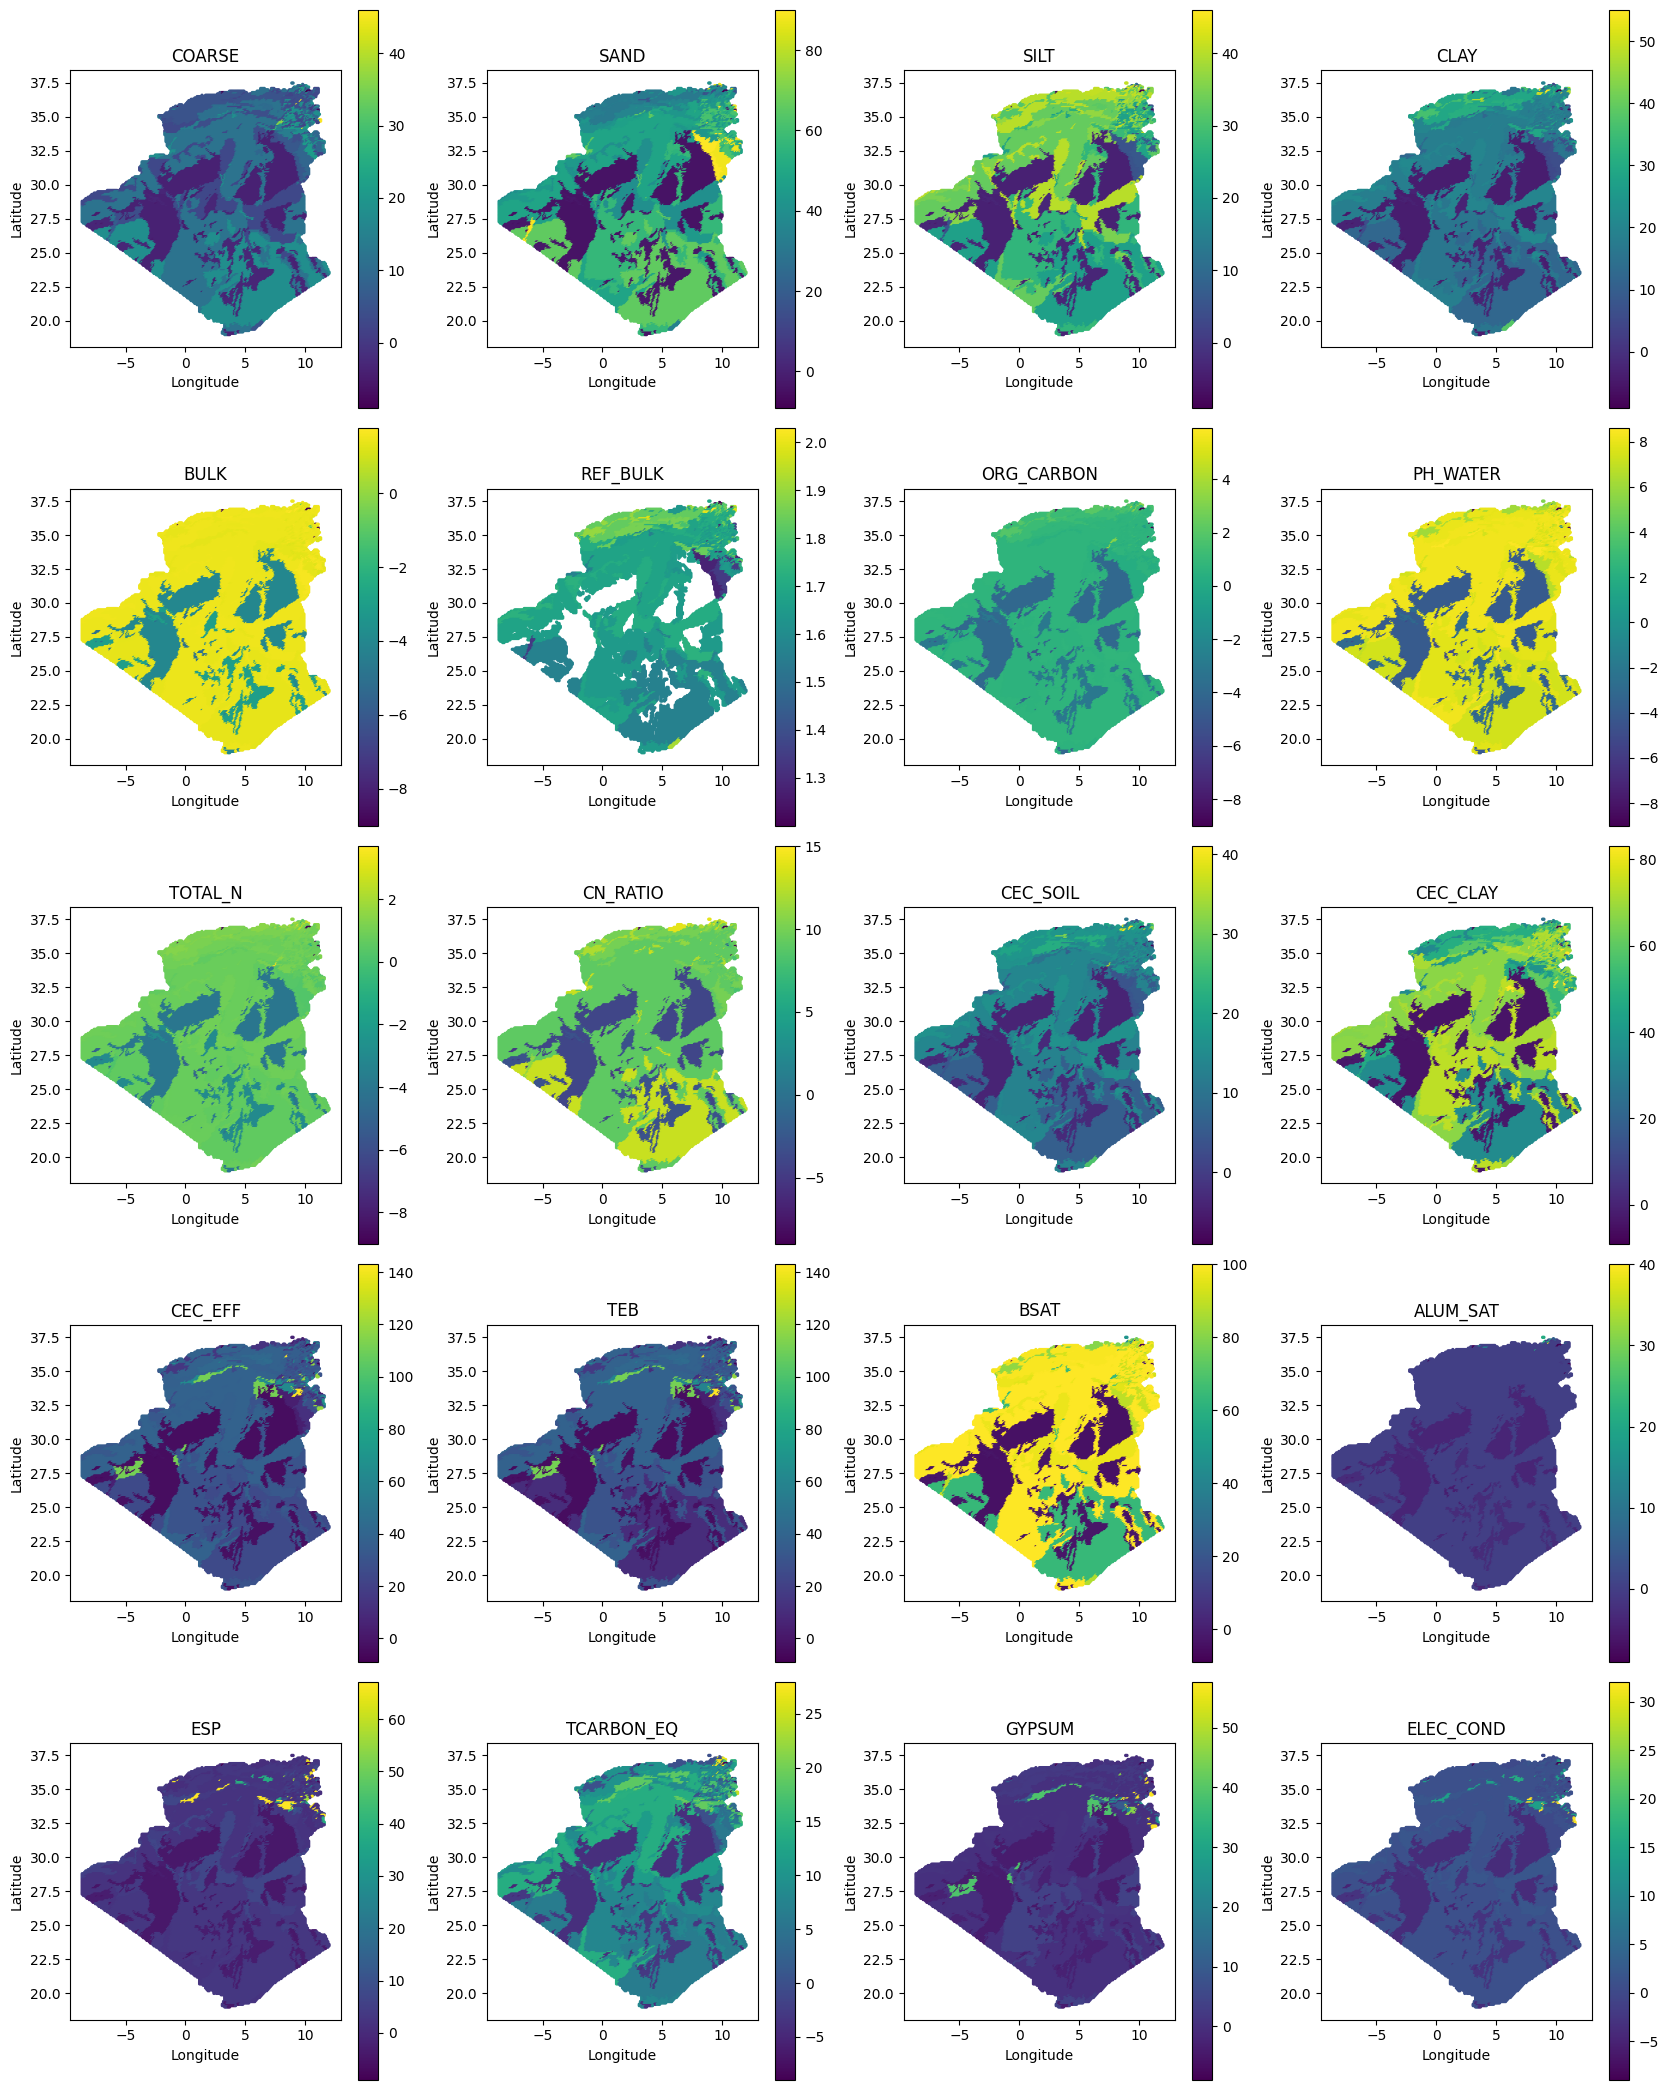

In [10]:
# Plot maps (subplots) showing spatial variation for each numeric column
# Ensure GeoDataFrame and CRS
if not isinstance(df_soil, gpd.GeoDataFrame) or 'geometry' not in df_soil.columns:
    df_soil = gpd.GeoDataFrame(
        df_soil,
        geometry=gpd.points_from_xy(df_soil['x'], df_soil['y']),
        crs="EPSG:4326"
    )
elif df_soil.crs is None:
    df_soil = df_soil.set_crs("EPSG:4326", allow_override=True)

# Deduplicate numeric_cols (PH_WATER is listed twice)
unique_numeric_cols = []
for c in numeric_cols:
    if c not in unique_numeric_cols and c in df_soil.columns:
        unique_numeric_cols.append(c)

n = len(unique_numeric_cols)
if n == 0:
    print("No numeric columns found to map.")
else:
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 4.2*nrows), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(unique_numeric_cols):
        ax = axes[i]
        series = df_soil[col]
        if series.dropna().empty:
            ax.text(0.5, 0.5, f"{col}\nNo data", ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        try:
            df_soil.plot(column=col, ax=ax, legend=True, cmap='viridis', markersize=2)
        except Exception as e:
            # Fallback: plot points without color if any issue
            df_soil.plot(ax=ax, color='gray', markersize=2)
            ax.text(0.5, 0.05, f"Failed to color by {col}: {e}", ha='center', va='bottom', transform=ax.transAxes, fontsize=8)
        ax.set_title(col)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # Hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    savefig('soil_maps_numeric_variation.png')
    plt.show()

In [11]:
# functionto calculate % of missing values
def missing_percentage(df):
    missing_count = df.isnull().sum().sum()
    total_count = df.size
    return (missing_count / total_count) * 100

In [12]:
#pourcentage of missing values in soil dataset
print(missing_percentage(df_soil),"%")

1.812133357142385 %


In [13]:
# extracting soil empty rows
df_missing_soil = df_soil[df_soil.isnull().any(axis=1)]

print("Number of rows with missing soil data:", df_missing_soil.shape[0])

Number of rows with missing soil data: 5480


In [14]:
# percentage of missing values in df_missing_soil for each column
print(df_missing_soil.isnull().mean() * 100)

y                  0.0
x                  0.0
HWSD2_SMU_ID       0.0
COARSE             0.0
SAND               0.0
SILT               0.0
CLAY               0.0
TEXTURE_USDA     100.0
TEXTURE_SOTER      0.0
BULK               0.0
REF_BULK         100.0
ORG_CARBON         0.0
PH_WATER           0.0
TOTAL_N            0.0
CN_RATIO           0.0
CEC_SOIL           0.0
CEC_CLAY           0.0
CEC_EFF            0.0
TEB                0.0
BSAT               0.0
ALUM_SAT           0.0
ESP                0.0
TCARBON_EQ         0.0
GYPSUM             0.0
ELEC_COND          0.0
geometry           0.0
dtype: float64


In [15]:
# check in df_missing_soil if  TEXTURE_USDA is missing  REF_BULK is not vise versa

print("Rows where both TEXTURE_USDA and REF_BULK are missing:")
# rows where both TEXTURE_USDA and REF_BULK are NOT missing (negative form: NOT)
print(df_missing_soil[(~(df_missing_soil['TEXTURE_USDA'].notnull()) & (df_missing_soil['REF_BULK'].notnull())) | (~(df_missing_soil['REF_BULK'].notnull()) & (df_missing_soil['TEXTURE_USDA'].notnull()))])


Rows where both TEXTURE_USDA and REF_BULK are missing:
Empty GeoDataFrame
Columns: [y, x, HWSD2_SMU_ID, COARSE, SAND, SILT, CLAY, TEXTURE_USDA, TEXTURE_SOTER, BULK, REF_BULK, ORG_CARBON, PH_WATER, TOTAL_N, CN_RATIO, CEC_SOIL, CEC_CLAY, CEC_EFF, TEB, BSAT, ALUM_SAT, ESP, TCARBON_EQ, GYPSUM, ELEC_COND, geometry]
Index: []

[0 rows x 26 columns]


In [16]:
#index of rows with missing soil data
missing_soil_indices = df_missing_soil.index.tolist()

print(missing_soil_indices)

[17, 140, 141, 142, 151, 152, 217, 218, 231, 1244, 1251, 1484, 1485, 1609, 1610, 1615, 2523, 3594, 3595, 3597, 3598, 3599, 3710, 3717, 3718, 3719, 3720, 3721, 3722, 3836, 3839, 3840, 3844, 3845, 3846, 3847, 3963, 3964, 3968, 3971, 3972, 4090, 4091, 4095, 4097, 4098, 4099, 4100, 4101, 4102, 4218, 4219, 4222, 4223, 4224, 4226, 4227, 4228, 4230, 4347, 4348, 4350, 4351, 4352, 4353, 4354, 4355, 4356, 4478, 4479, 4480, 4481, 4482, 4483, 4484, 4485, 4486, 4487, 4610, 4611, 4612, 4613, 4614, 4615, 4616, 4617, 4618, 4619, 4626, 4627, 4741, 4742, 4744, 4745, 4746, 4747, 4748, 4749, 4750, 4751, 4752, 4753, 4754, 4755, 4756, 4757, 4758, 4759, 4762, 4877, 4878, 4879, 4880, 4881, 4882, 4883, 4884, 4885, 4886, 4887, 4888, 4889, 4890, 4891, 4892, 4893, 5010, 5011, 5012, 5013, 5014, 5015, 5016, 5017, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5136, 5137, 5138, 5140, 5141, 5142, 5143, 5144, 5145, 5146, 5147, 5148, 5149, 5150, 5151, 5152, 5153, 5216, 5264, 5265, 5266, 5267, 5269, 5270, 5271, 5272, 5273, 5

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_scatter_texture_refbulk.png


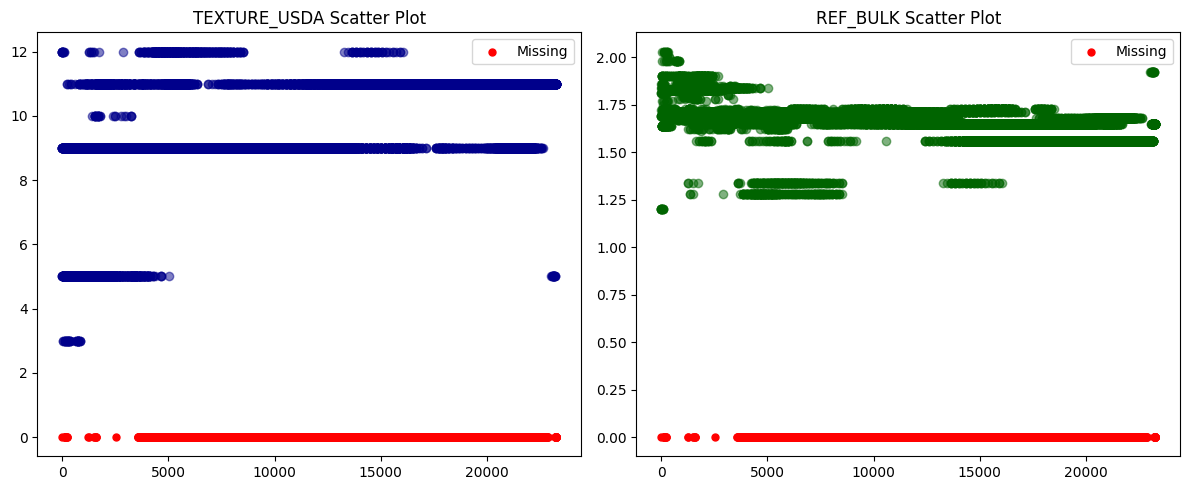

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TEXTURE_USDA
axes[0].scatter(df_soil.index, df_soil['TEXTURE_USDA'], color='darkblue', alpha=0.5)
axes[0].scatter(missing_soil_indices, [0] * len(missing_soil_indices),
                color='red', s=25, label='Missing')
axes[0].set_title("TEXTURE_USDA Scatter Plot")
axes[0].legend()

# REF_BULK
axes[1].scatter(df_soil.index, df_soil['REF_BULK'], color='darkgreen', alpha=0.5)
axes[1].scatter(missing_soil_indices, [0] * len(missing_soil_indices),
                color='red', s=25, label='Missing')
axes[1].set_title("REF_BULK Scatter Plot")
axes[1].legend()

plt.tight_layout()
savefig('soil_scatter_texture_refbulk.png')
plt.show()


In [18]:
#mean mode median of TEXTURE_USDA and REF_BULK
for col in ["TEXTURE_USDA", "REF_BULK"]:
    if col in df_soil.columns:
        mean_val = df_soil[col].mean()
        median_val = df_soil[col].median()
        mode_val = df_soil[col].mode()[0] if not df_soil[col].mode().empty else None
        print(f"{col} - Mean: {mean_val}, Median: {median_val}, Mode: {mode_val}")
    else:
        print(f"Column {col} not found in the dataset.")

TEXTURE_USDA - Mean: 9.630806433472051, Median: 9.0, Mode: 11.0
REF_BULK - Mean: 1.6557237422918123, Median: 1.6799999475479126, Mode: 1.6799999475479126


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_texture_refbulk.png


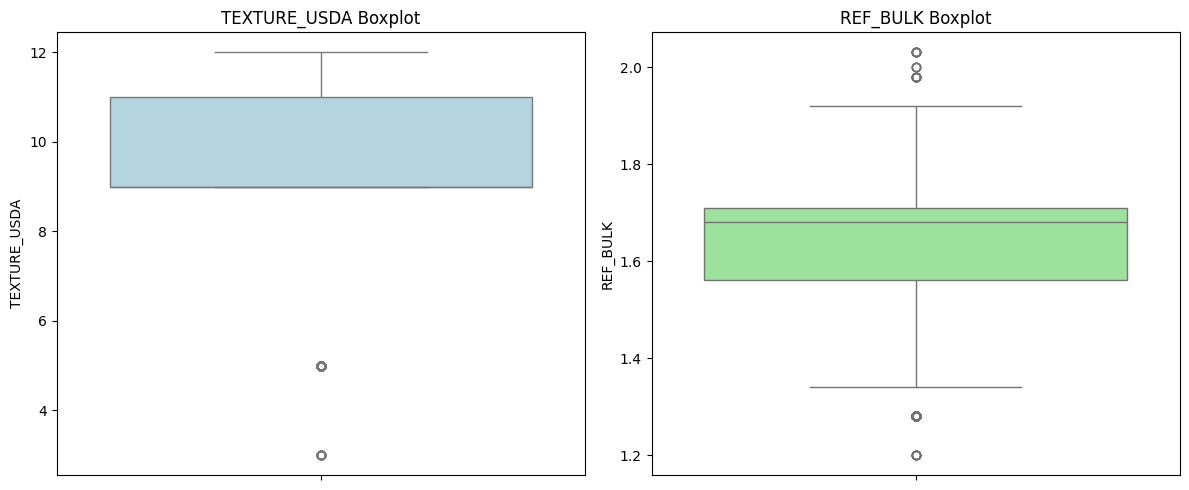

In [19]:
# boxplot values of TEXTURE_USDA and REF_BULK
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_soil['TEXTURE_USDA'], ax=axes[0], color='lightblue')
axes[0].set_title("TEXTURE_USDA Boxplot")
sns.boxplot(y=df_soil['REF_BULK'], ax=axes[1], color='lightgreen')
axes[1].set_title("REF_BULK Boxplot")
plt.tight_layout()
savefig('soil_boxplots_texture_refbulk.png')
plt.show()

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_texture_usda.png


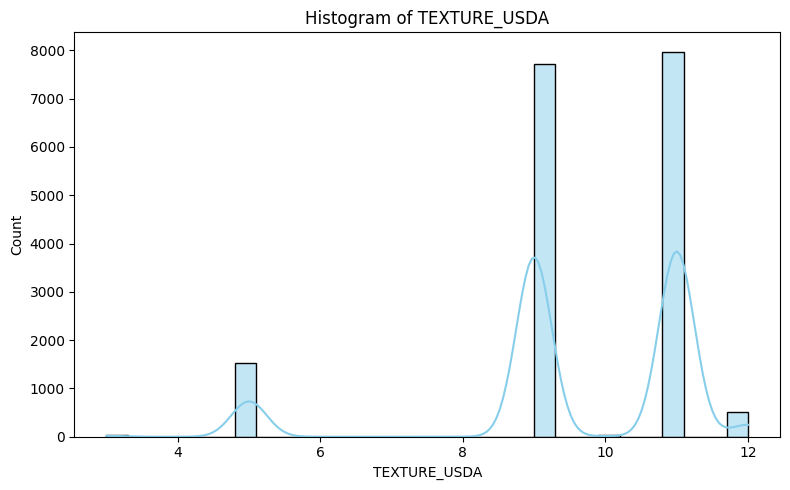

In [20]:
#histogram of TEXTURE_USDA
plt.figure(figsize=(8, 5))
sns.histplot(df_soil['TEXTURE_USDA'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Histogram of TEXTURE_USDA")
plt.xlabel('TEXTURE_USDA')
plt.ylabel('Count')
savefig('soil_hist_texture_usda.png')
plt.show()

In [21]:
# check in df_missing_soil if  TEXTURE_USDA is missing  REF_BULK is not vise versa

print("Rows where both TEXTURE_USDA and REF_BULK are missing:")
# rows where both TEXTURE_USDA and REF_BULK are NOT missing (negative form: NOT)
print(df_missing_soil[(~(df_missing_soil['TEXTURE_USDA'].notnull()) & (df_missing_soil['REF_BULK'].notnull())) | (~(df_missing_soil['REF_BULK'].notnull()) & (df_missing_soil['TEXTURE_USDA'].notnull()))])


Rows where both TEXTURE_USDA and REF_BULK are missing:
Empty GeoDataFrame
Columns: [y, x, HWSD2_SMU_ID, COARSE, SAND, SILT, CLAY, TEXTURE_USDA, TEXTURE_SOTER, BULK, REF_BULK, ORG_CARBON, PH_WATER, TOTAL_N, CN_RATIO, CEC_SOIL, CEC_CLAY, CEC_EFF, TEB, BSAT, ALUM_SAT, ESP, TCARBON_EQ, GYPSUM, ELEC_COND, geometry]
Index: []

[0 rows x 26 columns]


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_ecdf_ref_bulk.png


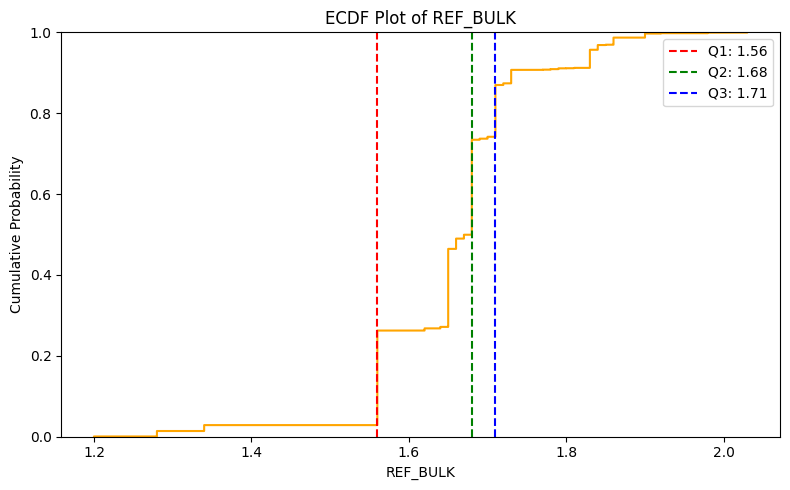

In [22]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(df_soil['REF_BULK'].dropna(), color='orange')
plt.title("ECDF Plot of REF_BULK")

# Calculate quartiles
ref_bulk_clean = df_soil['REF_BULK'].dropna()
q1 = ref_bulk_clean.quantile(0.25)
q2 = ref_bulk_clean.quantile(0.50)  # median
q3 = ref_bulk_clean.quantile(0.75)

# Add vertical lines for quartiles
plt.axvline(q1, color='red', linestyle='--', linewidth=1.5, label=f'Q1: {q1:.2f}')
plt.axvline(q2, color='green', linestyle='--', linewidth=1.5, label=f'Q2: {q2:.2f}')
plt.axvline(q3, color='blue', linestyle='--', linewidth=1.5, label=f'Q3: {q3:.2f}')

plt.xlabel('REF_BULK')
plt.ylabel('Cumulative Probability')
plt.legend()
savefig('soil_ecdf_ref_bulk.png')
plt.show()

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_ref_bulk.png


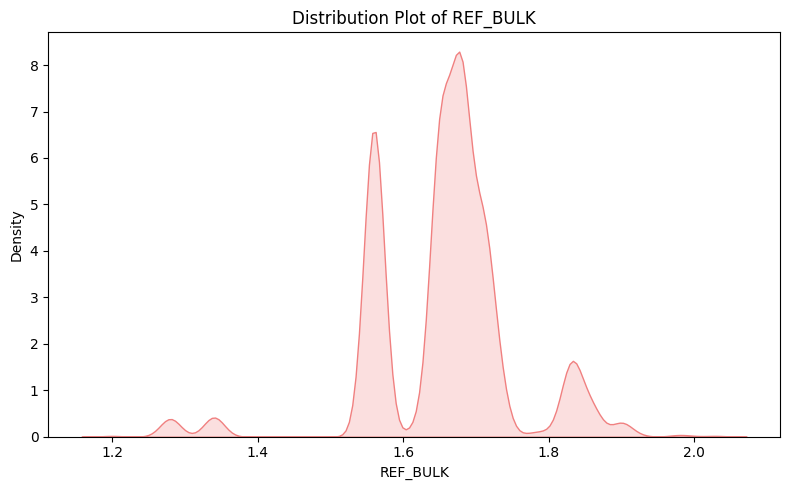

In [23]:
#distribution plot of REF_BULK
plt.figure(figsize=(8, 5))
sns.kdeplot(df_soil['REF_BULK'].dropna(), fill=True, color='lightcoral')
plt.title("Distribution Plot of REF_BULK")
plt.xlabel('REF_BULK')
plt.ylabel('Density')
savefig('soil_kde_ref_bulk.png')
plt.show()

## removing missing values

In [24]:
#simple imputer (median) for REF_Bulk
imputer = SimpleImputer(strategy='median')
df_soil['REF_BULK'] = imputer.fit_transform(df_soil[['REF_BULK']])

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_ref_bulk_after_imputation.png


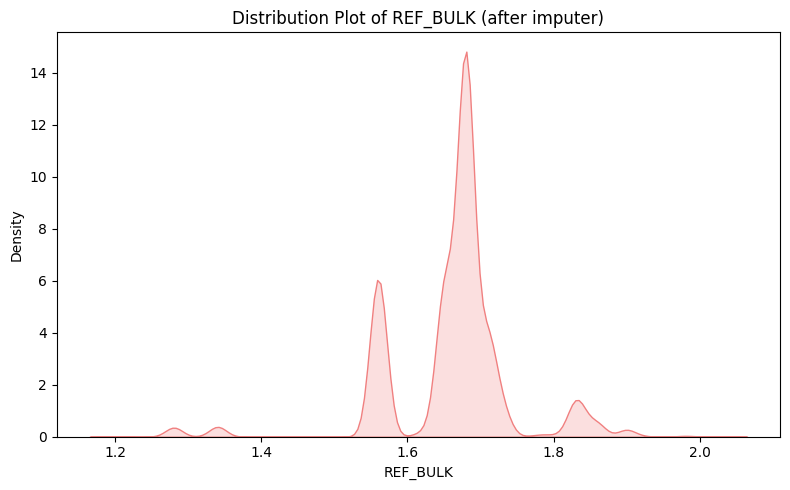

In [25]:
#distribution plot of REF_BULK
plt.figure(figsize=(8, 5))
sns.kdeplot(df_soil['REF_BULK'].dropna(), fill=True, color='lightcoral')
plt.title("Distribution Plot of REF_BULK (after imputer)")
savefig('soil_kde_ref_bulk_after_imputation.png')


In [26]:
# Known classes only
known = df_soil[df_soil['TEXTURE_USDA'].notna()].copy()
known['TEXTURE_USDA'] = known['TEXTURE_USDA'].astype(int)

# distribution
counts = known['TEXTURE_USDA'].value_counts().sort_index()
print("Class min:", counts.index.min(), " Class max:", counts.index.max())
print(counts)


Class min: 3  Class max: 12
TEXTURE_USDA
3       37
5     1517
9     7717
10      26
11    7974
12     511
Name: count, dtype: int64


In [27]:
# features to use for centroid calculation
features = ['SAND', 'SILT', 'CLAY']

# select known rows
known = df_soil[df_soil['TEXTURE_USDA'].notna()].copy()
known['TEXTURE_USDA'] = known['TEXTURE_USDA'].astype(int)

# scale features for fair comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(known[features])

# add scaled features back for mean computation
known_scaled = pd.DataFrame(X_scaled, columns=features, index=known.index)
known_scaled['TEXTURE_USDA'] = known['TEXTURE_USDA']

# compute centroid (mean per class)
centroids = known_scaled.groupby('TEXTURE_USDA')[features].mean()
print("Centroids (mean composition per class):")
print(centroids)


Centroids (mean composition per class):
                  SAND      SILT      CLAY
TEXTURE_USDA                              
3            -3.071266  0.639618  5.895361
5            -1.597866  0.837086  2.374710
9            -0.608907  0.777486  0.275428
10           -0.136714 -0.875670  1.503820
11            0.717967 -0.707282 -0.612346
12            2.964820 -3.191287 -2.157137


In [28]:
# rows with missing TEXTURE_USDA
missing = df_soil[df_soil['TEXTURE_USDA'].isna()].copy()

# scale their features using same scaler
X_missing = scaler.transform(missing[features])

# compute Euclidean distance to each centroid
distances = cdist(X_missing, centroids.values, metric='euclidean')

# pick nearest class
nearest_class = centroids.index[np.argmin(distances, axis=1)]

# fill missing values
df_soil.loc[missing.index, 'TEXTURE_USDA'] = nearest_class


In [29]:
print("Remaining NaNs:", df_soil['TEXTURE_USDA'].isna().sum())

# new class distribution
dist_after = df_soil['TEXTURE_USDA'].astype(int).value_counts().sort_index()
print("\nNew class distribution after smart imputation:")
print(dist_after)


Remaining NaNs: 0

New class distribution after smart imputation:
TEXTURE_USDA
3        37
5      1517
9      7717
10       26
11    13454
12      511
Name: count, dtype: int64


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_texture_usda_after_imputer.png


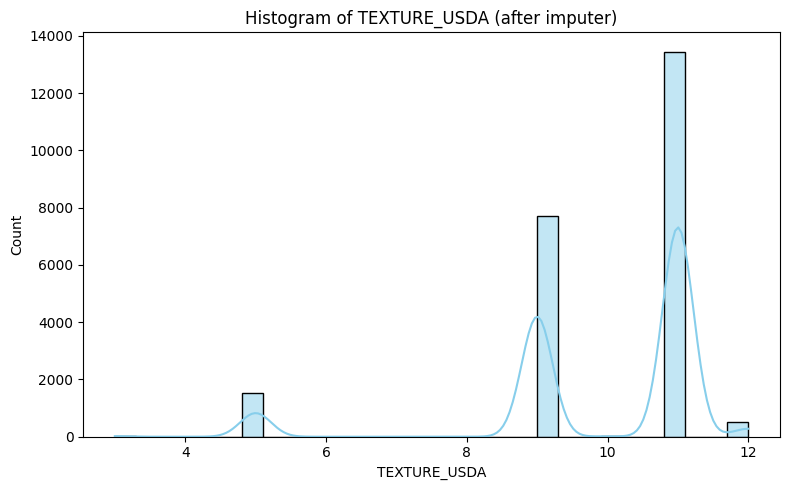

In [30]:
#histogram of TEXTURE_USDA
plt.figure(figsize=(8, 5))
sns.histplot(df_soil['TEXTURE_USDA'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Histogram of TEXTURE_USDA (after imputer)")
plt.xlabel('TEXTURE_USDA')
plt.ylabel('Count')
savefig('soil_hist_texture_usda_after_imputer.png')
plt.show()

# Data analysis

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_scatter_numeric.png


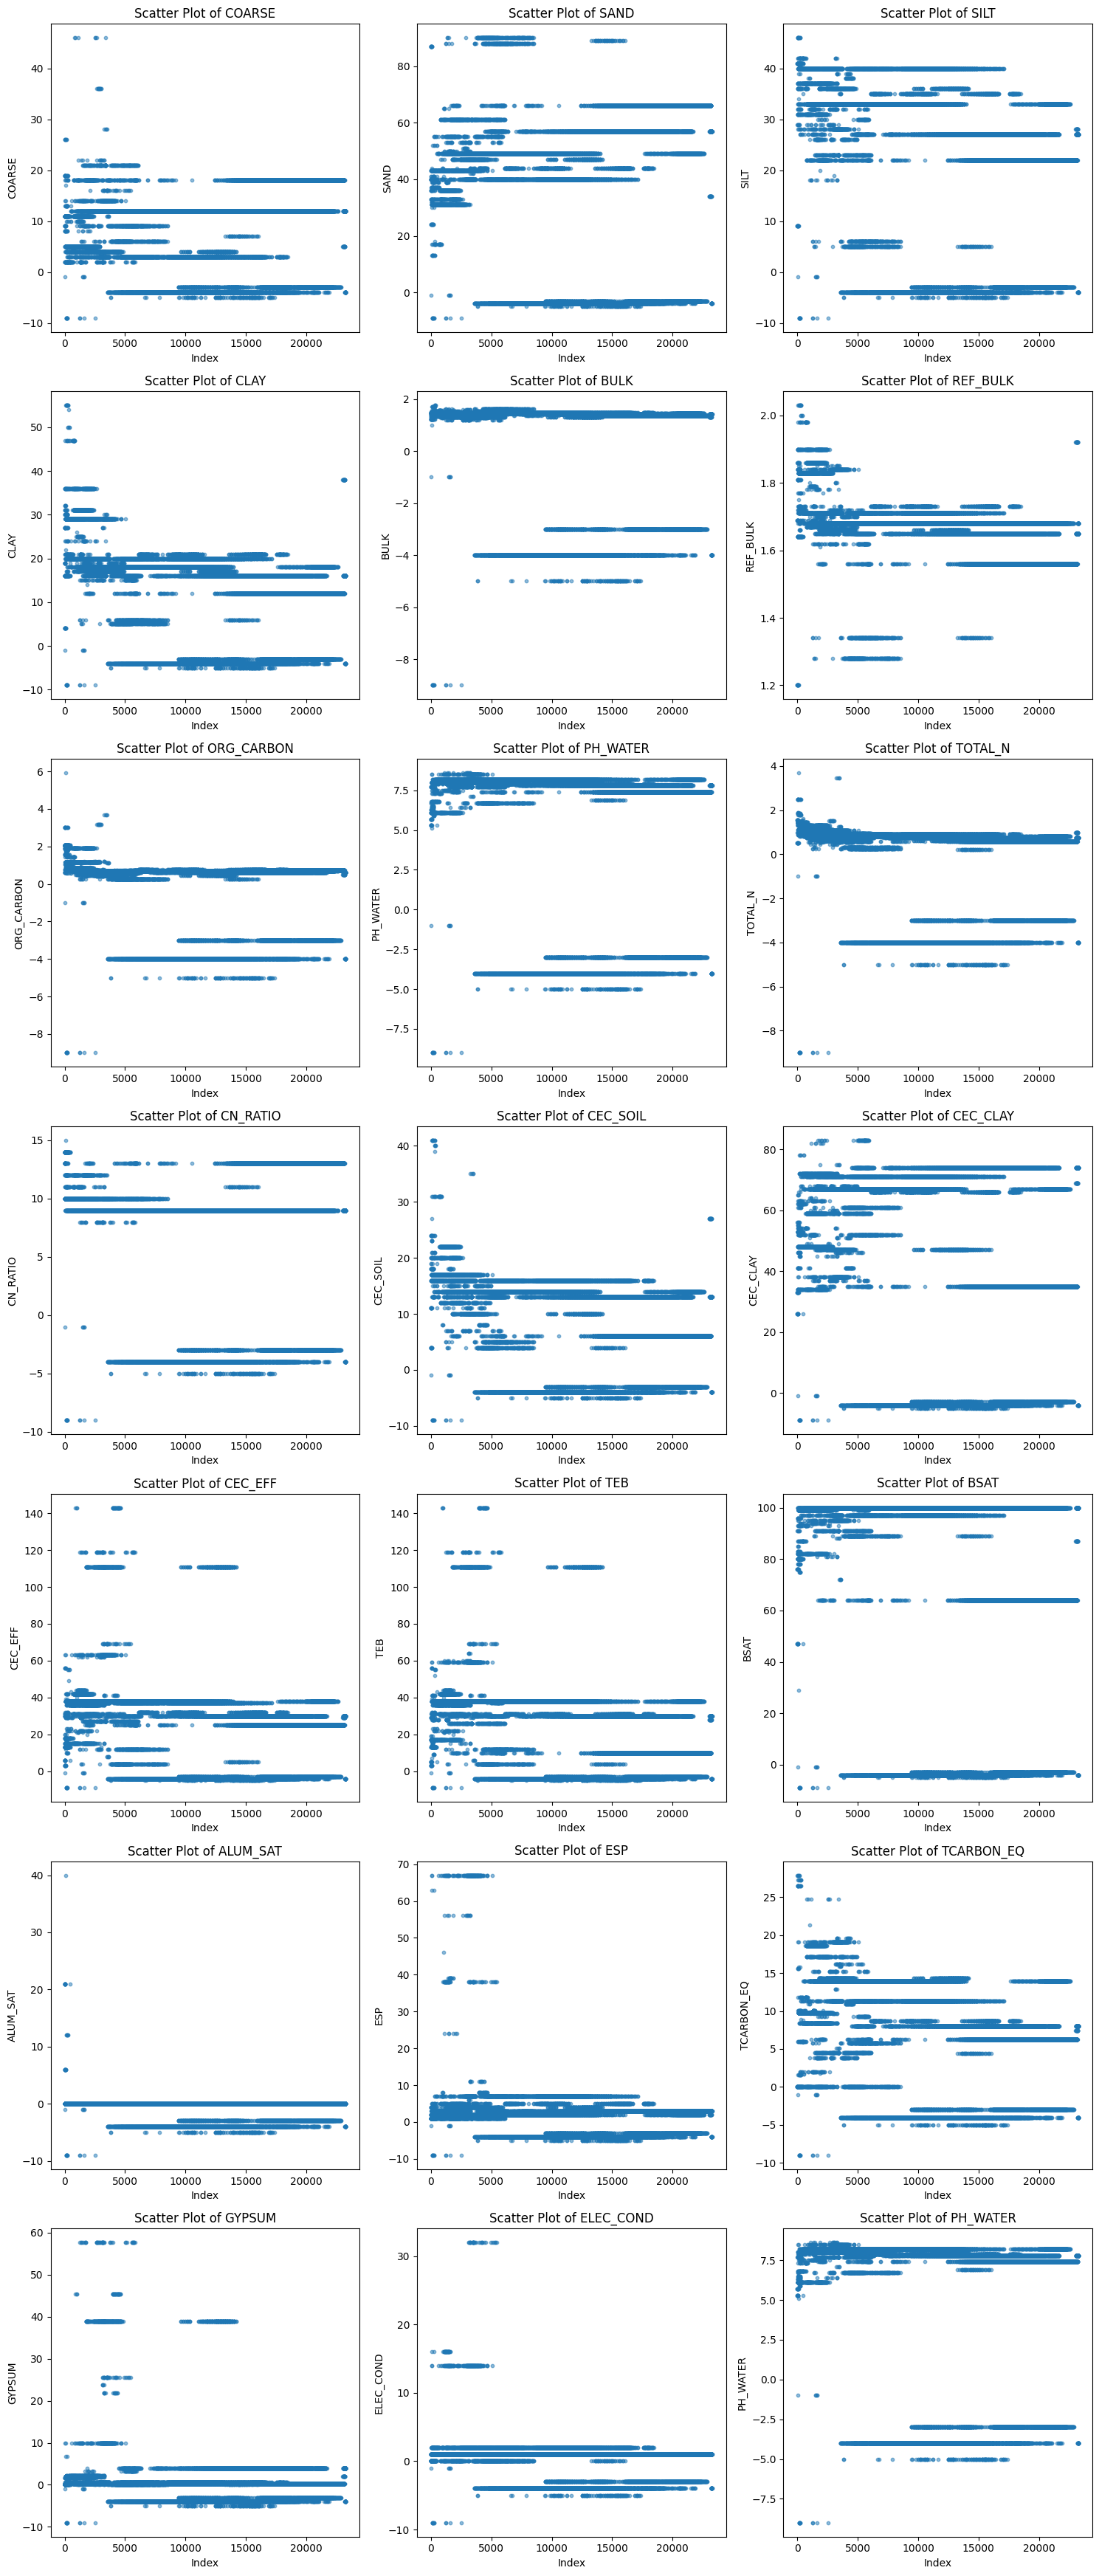

In [31]:
# Create subplots for numeric columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 columns per row

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df_soil.index, df_soil[col], alpha=0.5, s=10)
    axes[i].set_title(f"Scatter Plot of {col}")
    axes[i].set_xlabel("Index")
    axes[i].set_ylabel(col)

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
savefig('soil_scatter_numeric.png')
plt.show()

In [32]:
#dataframe of mean, median, mode, min, max, midrange, range for numeric_cols
numeric_summary = pd.DataFrame({
    'mean': df_soil[numeric_cols].mean(),
    'median': df_soil[numeric_cols].median(),
    'mode': df_soil[numeric_cols].mode().iloc[0],
    'min': df_soil[numeric_cols].min(),
    'max': df_soil[numeric_cols].max(),
    'midrange': (df_soil[numeric_cols].min() + df_soil[numeric_cols].max()) / 2,
    'range': df_soil[numeric_cols].max() - df_soil[numeric_cols].min()
})

In [33]:
numeric_summary

,mean,median,mode,min,max,midrange,range
COARSE,7.777534,12.000,12.000,-9.0,46.000000,18.500000,55.000000
SAND,39.715115,49.000,66.000,-9.0,90.000000,40.500000,99.000000
SILT,21.707678,27.000,33.000,-9.0,46.000000,18.500000,55.000000
CLAY,12.355300,16.000,18.000,-9.0,55.000000,23.000000,64.000000
BULK,0.203762,1.430,1.450,-9.0,1.760000,-3.620000,10.760000
REF_BULK,1.661443,1.680,1.680,1.2,2.030000,1.615000,0.830000
ORG_CARBON,-0.339876,0.695,0.711,-9.0,5.923000,-1.538500,14.923000
PH_WATER,5.104118,7.800,8.200,-9.0,8.600000,-0.200000,17.600000
TOTAL_N,-0.299301,0.730,0.580,-9.0,3.690000,-2.655000,12.690000
CN_RATIO,6.823317,9.000,9.000,-9.0,15.000000,3.000000,24.000000


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_numeric_annotated.png


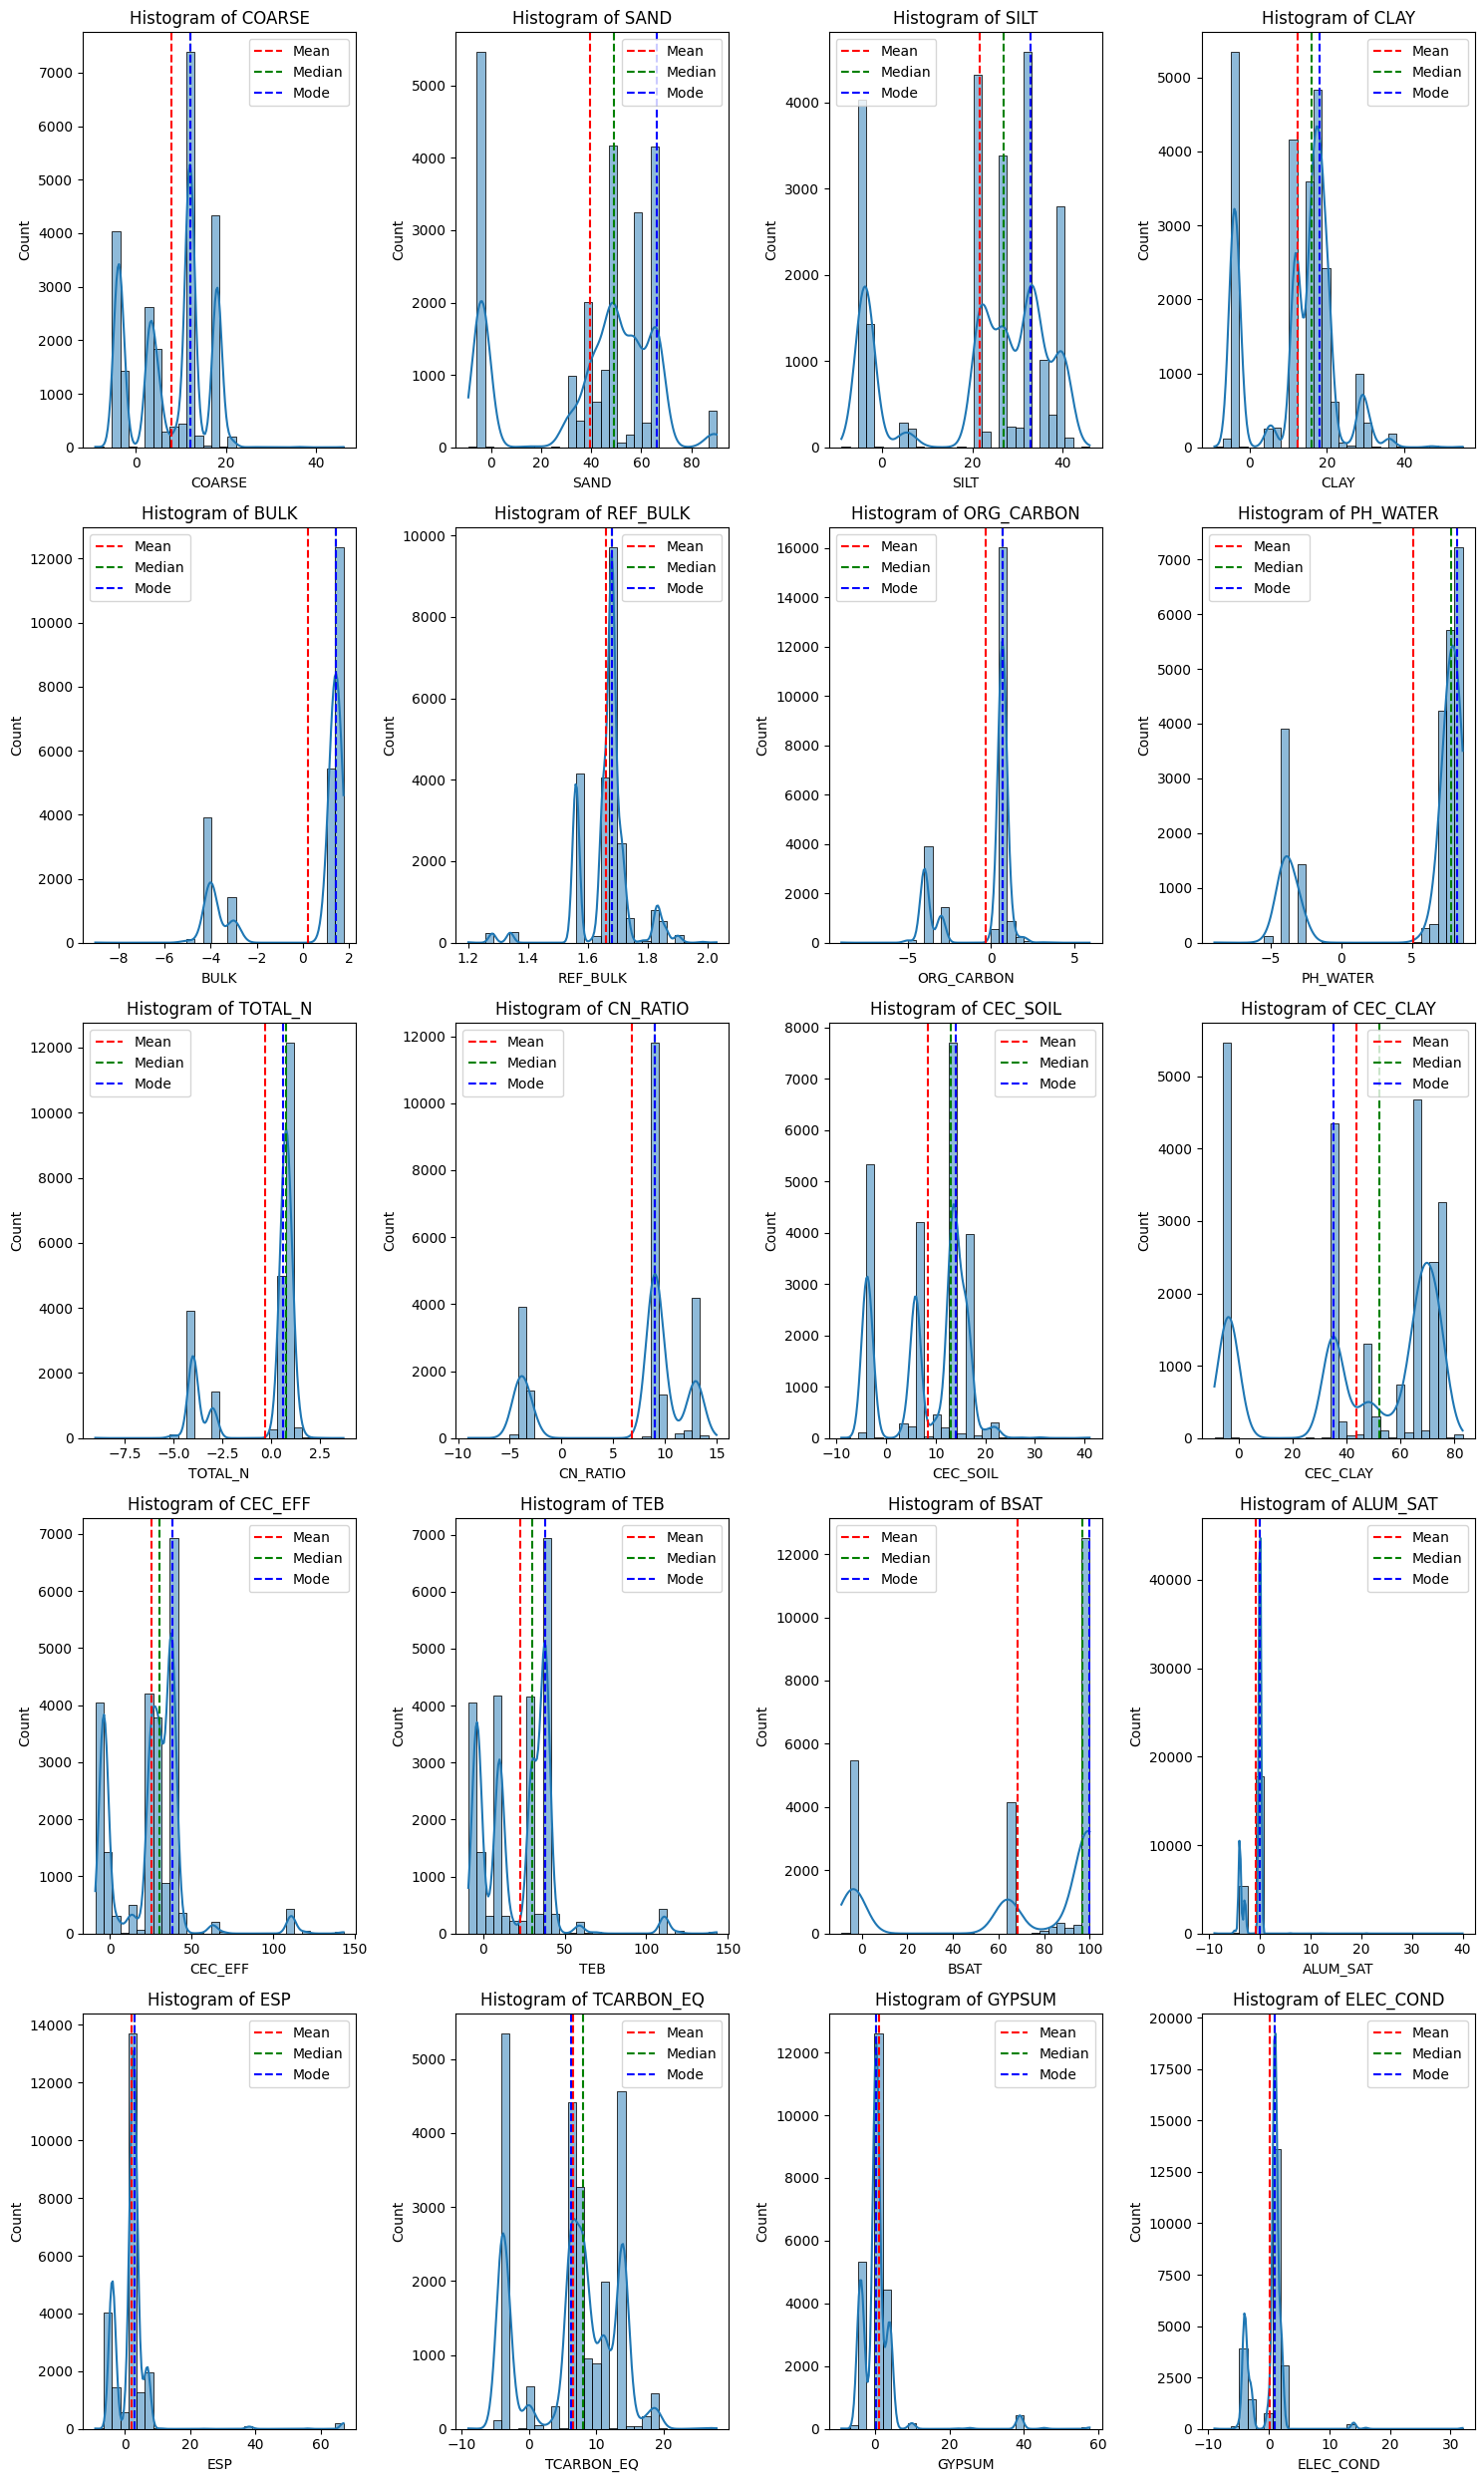

In [34]:
# Plot histograms for numeric columns and annotate with numeric_summary stats
# avoid duplicating columns (e.g. PH_WATER appears twice in numeric_cols)
unique_cols = []
for c in numeric_cols:
    if c not in unique_cols:
        unique_cols.append(c)

n_cols_plot = len(unique_cols)
n_rows_plot = (n_cols_plot + 2) // 4

fig = plt.figure(figsize=(15, 5 * n_rows_plot))
for i, col in enumerate(unique_cols):
    ax = plt.subplot(n_rows_plot, 4, i + 1)
    data = df_soil[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax)
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    # numeric_summary may contain duplicate index entries; ensure scalars
    def _to_scalar(v):
        if isinstance(v, (pd.Series, np.ndarray, list, tuple)):
            try:
                return float(v.iloc[0]) if isinstance(v, pd.Series) else float(v[0])
            except Exception:
                return float(v)
        return float(v)

    mean_val = _to_scalar(numeric_summary.loc[col, 'mean'])
    median_val = _to_scalar(numeric_summary.loc[col, 'median'])
    mode_val = _to_scalar(numeric_summary.loc[col, 'mode'])

    ax.axvline(mean_val, color='r', linestyle='--', label='Mean')
    ax.axvline(median_val, color='g', linestyle='--', label='Median')
    ax.axvline(mode_val, color='b', linestyle='--', label='Mode')
    ax.legend()

plt.tight_layout()
savefig('soil_hist_numeric_annotated.png')
plt.show()

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_qq_numeric.png


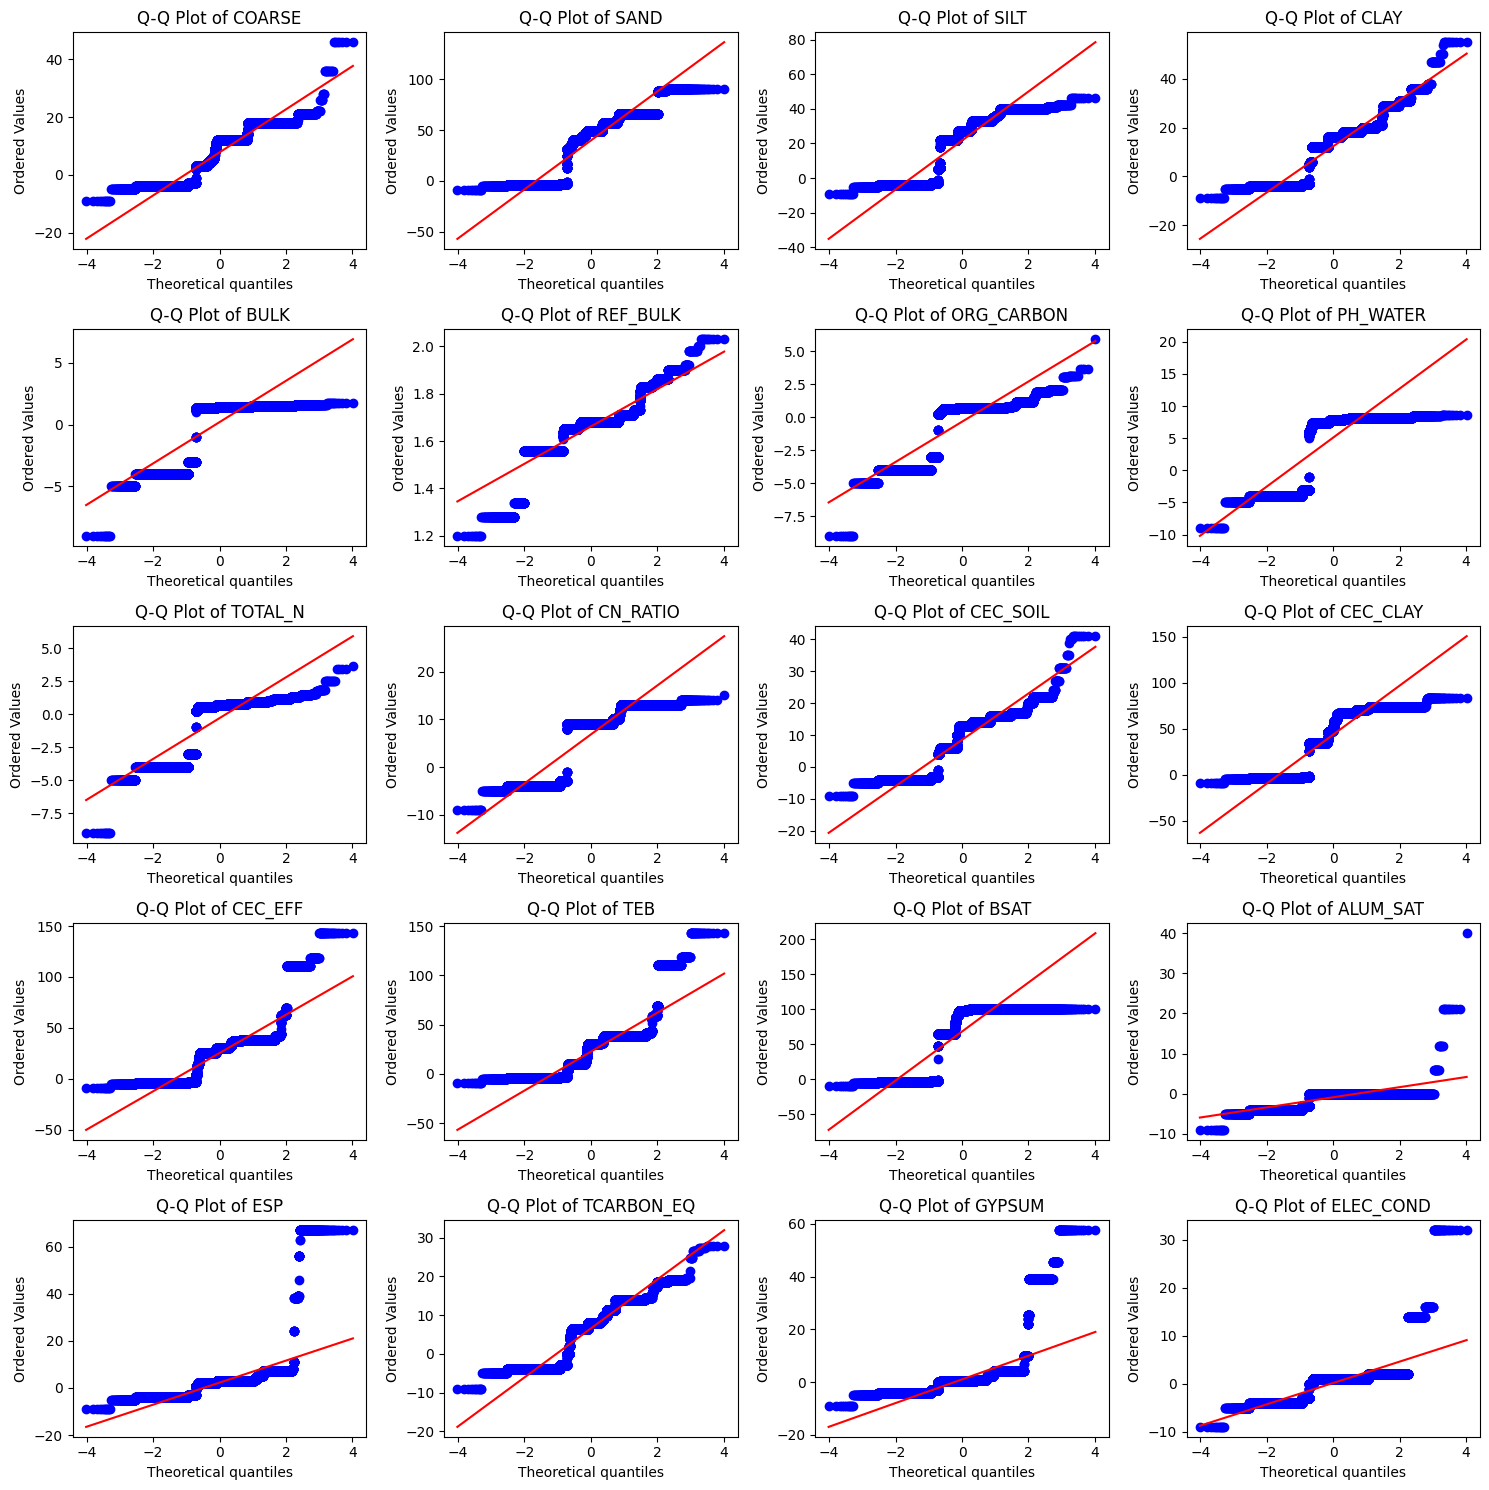

In [35]:
#quantile plot for numeric columns
plt.figure(figsize=(15, 15))

# use unique_cols (no duplicated columns) and the already computed n_rows_plot
for i, col in enumerate(unique_cols, 1):
    plt.subplot(n_rows_plot, 4, i)
    stats.probplot(df_soil[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")

plt.tight_layout()
savefig('soil_qq_numeric.png')
plt.show()


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_numeric.png


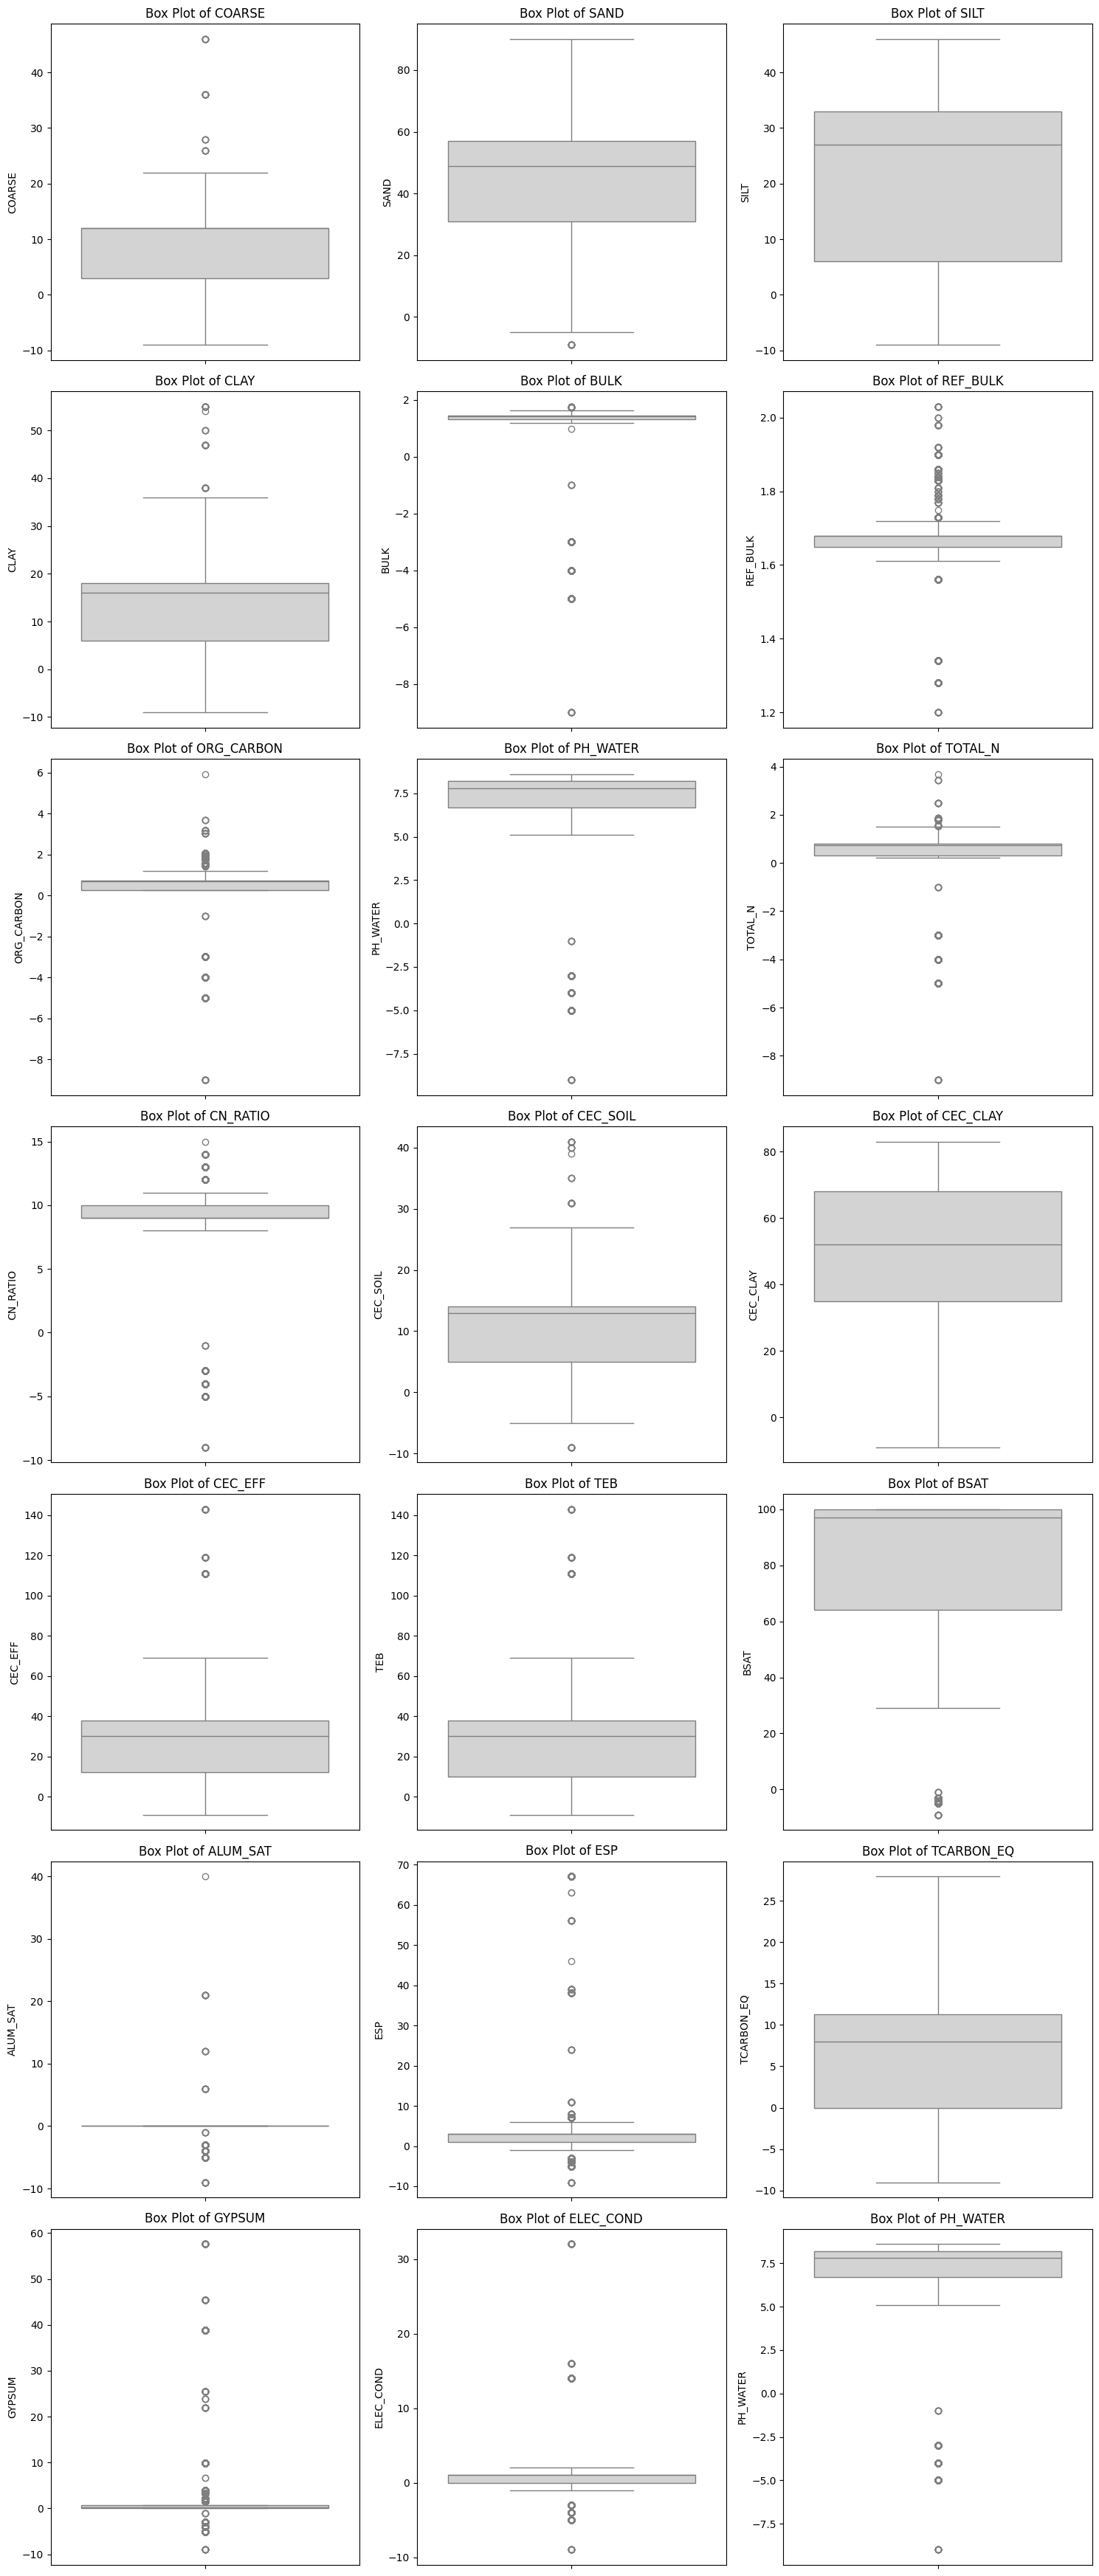

In [36]:
# box plots for numeric columns
fig_box, axes_box = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes_flat = axes_box.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_soil[col], ax=axes_flat[i], color='lightgray')
    axes_flat[i].set_title(f"Box Plot of {col}")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel(col)

# Hide any unused axes (safety)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
savefig('soil_boxplots_numeric.png')
plt.show()

## **Aalysing Outliers**

In [37]:
def detect_outliers(df, columns, multiplier=1.5, verbose=True):
    if columns is None:
        columns = df.select_dtypes(include='number').columns.tolist()
    total_outliers = {}
    df_clean = df.copy()

    for col in columns:
        total_outliers[col] = []
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        total_outliers[col] = outliers.index.tolist()
        if verbose:
            print(f"Column: {col} | Detected outliers: {len(outliers)}")
    
        
    

In [38]:
def remove_outliers_iqr(df, columns=None, multiplier=1.5, verbose=True):
    """
    Removes outliers from numerical columns using the IQR (Interquartile Range) method.
    
    Parameters
    ----------
    df : pd.DataFrame
        The input DataFrame.
    columns : list, optional
        List of column names to apply IQR filtering.
        If None, all numeric columns are processed.
    multiplier : float, optional (default=1.5)
        The IQR multiplier. Common values:
          - 1.5 = standard
          - 3.0 = conservative (fewer removed)
    verbose : bool
        If True, prints summary of removed rows per column.

    Returns
    -------
    pd.DataFrame
        DataFrame with outliers removed.
    """

    if columns is None:
        columns = df.select_dtypes(include='number').columns.tolist()

    df_clean = df.copy()
    total_removed = 0

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        removed = before - len(df_clean)
        total_removed += removed
        
        if verbose and removed > 0:
            print(f"Column '{col}': removed {removed} outliers (bounds: {lower_bound:.2f}, {upper_bound:.2f})")

    if verbose:
        print(f"\n Total rows removed: {total_removed}")
        print(f"Remaining rows: {len(df_clean)}")

    return df_clean


In [39]:
#show outliers for numeric columns

outliers = detect_outliers(df_soil, numeric_cols, multiplier=1.5, verbose=True)

Column: COARSE | Detected outliers: 28
Column: SAND | Detected outliers: 12
Column: SILT | Detected outliers: 0
Column: CLAY | Detected outliers: 53
Column: BULK | Detected outliers: 5495
Column: REF_BULK | Detected outliers: 6911
Column: ORG_CARBON | Detected outliers: 5849
Column: PH_WATER | Detected outliers: 5480
Column: TOTAL_N | Detected outliers: 5533
Column: CN_RATIO | Detected outliers: 9976
Column: CEC_SOIL | Detected outliers: 53
Column: CEC_CLAY | Detected outliers: 0
Column: CEC_EFF | Detected outliers: 506
Column: TEB | Detected outliers: 506
Column: BSAT | Detected outliers: 5480
Column: ALUM_SAT | Detected outliers: 5508
Column: ESP | Detected outliers: 7736
Column: TCARBON_EQ | Detected outliers: 0
Column: GYPSUM | Detected outliers: 10961
Column: ELEC_COND | Detected outliers: 5756
Column: PH_WATER | Detected outliers: 5480


In [40]:
print("BULK:",(df_soil[df_soil['BULK'] < 0].value_counts()
).sum())
print("REF_BULK:",(df_soil[df_soil['REF_BULK'] < 0].value_counts()
).sum())
print("PH_WATER:",(df_soil[df_soil['PH_WATER'] < 0].value_counts()
).sum())
print("ORG_CARBON:",(df_soil[df_soil['ORG_CARBON'] < 0].value_counts()
).sum())
print("ELEC_COND:",(df_soil[df_soil['ELEC_COND'] < 0].value_counts()
).sum())
print("TOTAL_N:",(df_soil[df_soil['TOTAL_N'] < 0].value_counts()
).sum())
print("CN_RATIO:",(df_soil[df_soil['CN_RATIO'] < 0].value_counts()
).sum())
print("BSAT:",(df_soil[df_soil['BSAT'] < 0].value_counts()
).sum())
print("ALUM_SAT:",(df_soil[df_soil['ALUM_SAT'] < 0].value_counts()
).sum())
print("ESP:",(df_soil[df_soil['ESP'] < 0].value_counts()
).sum())
print("GYPSUM:",(df_soil[df_soil['GYPSUM'] < 0].value_counts()
).sum())


BULK: 5480
REF_BULK: 0
PH_WATER: 5480
ORG_CARBON: 5480
ELEC_COND: 5480
TOTAL_N: 5480
CN_RATIO: 5480
BSAT: 5480
ALUM_SAT: 5480
ESP: 5480
GYPSUM: 5480


In [41]:
#verifying if 
# BULK: 5480
# PH_WATER: 5480
# ORG_CARBON: 5480
# ELEC_COND: 5480
# TOTAL_N: 5480
# CN_RATIO: 5480
# BSAT: 5480
# ALUM_SAT: 5480
# ESP: 5480
# GYPSUM: 5480
# rows where ALL listed columns are negative
invalid_soil_indices = df_soil[
    (df_soil['BULK'] < 0) &
    (df_soil['ORG_CARBON'] < 0) &
    (df_soil['ELEC_COND'] < 0) &
    (df_soil['TOTAL_N'] < 0) &
    (df_soil['PH_WATER'] < 0) &
    (df_soil['CN_RATIO'] < 0) &
    (df_soil['BSAT'] < 0) &
    (df_soil['ALUM_SAT'] < 0) &
    (df_soil['ESP'] < 0) &
    (df_soil['GYPSUM'] < 0)
].index.tolist()
print("Number of rows with ALL negative values (across listed columns):", len(invalid_soil_indices))

Number of rows with ALL negative values (across listed columns): 5480


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_invalid_negative_spatial_distribution.png


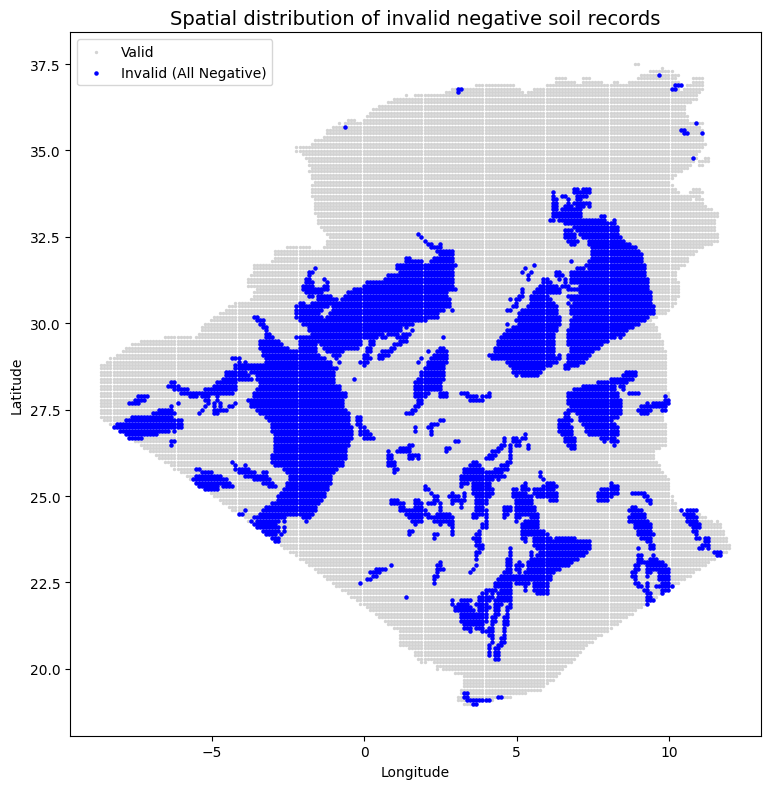

In [42]:
# convert to GeoDataFrame (assuming lat/lon columns exist)
df_soil = gpd.GeoDataFrame(
    df_soil,
    geometry=gpd.points_from_xy(df_soil['x'], df_soil['y']),
    crs="EPSG:4326"  # WGS84
)
invalid_mask = (
    (df_soil[['BULK','ORG_CARBON','ELEC_COND','TOTAL_N','PH_WATER',
              'CN_RATIO','BSAT','ALUM_SAT','ESP','GYPSUM']] < 0)
).all(axis=1)

valid_mask = ~invalid_mask
# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
# Plot valid points (light gray)
df_soil.loc[valid_mask].plot(ax=ax, color="lightgray", markersize=2, label="Valid")
# Plot invalid points (blue)
df_soil.loc[invalid_mask].plot(ax=ax, color="blue", markersize=5, label="Invalid (All Negative)")

ax.set_title("Spatial distribution of invalid negative soil records", fontsize=14)
ax.legend()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
savefig('soil_invalid_negative_spatial_distribution.png')
plt.show()

## **Treating Outliers**

### **invalid rows**

In [43]:
#print each column values of row number 17
print(df_soil.loc[17])

y                                                  37.191667
x                                                   9.683333
HWSD2_SMU_ID                                           31800
COARSE                                                    -1
SAND                                                      -1
SILT                                                      -1
CLAY                                                      -1
TEXTURE_USDA                                            11.0
TEXTURE_SOTER                                              -
BULK                                                    -1.0
REF_BULK                                                1.68
ORG_CARBON                                              -1.0
PH_WATER                                                -1.0
TOTAL_N                                                 -1.0
CN_RATIO                                                -1.0
CEC_SOIL                                                  -1
CEC_CLAY                

In [44]:
#column 'is_invalid' to mark invalid rows
df_soil['is_invalid'] = invalid_mask
df_soil['is_invalid'].value_counts()

is_invalid
False    17782
True      5480
Name: count, dtype: int64

In [45]:
# 0) CONFIG
protect_cols = ['x','y','geometry','HWSD2_SMU_ID']        # never overwrite

# Physical columns we validate for negativity
phys_cols = ['BULK','ORG_CARBON','ELEC_COND','TOTAL_N','PH_WATER',
             'CN_RATIO','BSAT','ALUM_SAT','ESP','GYPSUM', 'REF_BULK']
print(phys_cols)

# Only fill the physical columns (do NOT include flags like 'is_invalid')
cols_to_fill = [c for c in phys_cols if c in df_soil.columns]
print('Columns to fill:', cols_to_fill)


['BULK', 'ORG_CARBON', 'ELEC_COND', 'TOTAL_N', 'PH_WATER', 'CN_RATIO', 'BSAT', 'ALUM_SAT', 'ESP', 'GYPSUM', 'REF_BULK']
Columns to fill: ['BULK', 'ORG_CARBON', 'ELEC_COND', 'TOTAL_N', 'PH_WATER', 'CN_RATIO', 'BSAT', 'ALUM_SAT', 'ESP', 'GYPSUM', 'REF_BULK']


In [46]:
# 1) Ensure we have lat/lon in radians for haversine
# If you already have geometry in EPSG:4326
if df_soil.crs is None or df_soil.crs.to_epsg() != 4326:
    df_soil = df_soil.set_crs("EPSG:4326", allow_override=True)

df_soil['y'] = df_soil.geometry.y
df_soil['x'] = df_soil.geometry.x
coords_rad = np.deg2rad(df_soil[['y','x']].to_numpy())

valid_idx = np.where(~df_soil['is_invalid'].to_numpy())[0]
invalid_idx = np.where(df_soil['is_invalid'].to_numpy())[0]


In [47]:
# 3) Build BallTree on VALID points only (haversine)
tree = BallTree(coords_rad[valid_idx], metric='haversine')

# 4) kNN search (choose k and a max radius if you want)
k = 8  # neighbors
# radius in meters ~ 100km; haversine returns radians, Earth radius ~ 6_371_000 m
max_radius_rad = 100_000 / 6_371_000


In [48]:
# 5) Impute per-column by median of neighbors (robust), keep audit trail
for bad_i in invalid_idx:
    # query neighbors for this invalid point
    dist_rad, nn_pos = tree.query(coords_rad[bad_i:bad_i+1], k=k, return_distance=True)
    dist_rad = dist_rad.ravel()
    nn_pos = nn_pos.ravel()
    # optional: filter by radius
    keep = dist_rad <= max_radius_rad
    nn_pos = nn_pos[keep]
    if nn_pos.size == 0:
        # fallback: take at least the k nearest, even if > radius
        nn_pos = tree.query(coords_rad[bad_i:bad_i+1], k=k, return_distance=False).ravel()

    # map positions back to original df indices
    neigh_indices = valid_idx[nn_pos]

    # fill each column by median of neighbors (ignoring NaN)
    for c in cols_to_fill:
        neigh_vals = df_soil.loc[neigh_indices, c].replace([-np.inf, np.inf], np.nan).dropna()
        if len(neigh_vals):
            if c in nominal_columns:
                # mode for nominal columns
                val = neigh_vals.mode().iloc[0]
            else:
                val = float(neigh_vals.median())

            # # enforce bounds
            # lo, hi = bounds.get(c, (None, None))
            # if lo is not None:
            #     val = max(val, lo)
            # if hi is not None:
            #     val = min(val, hi)

            df_soil.at[bad_i, c] = val
        else:
            # if no neighbor values exist, leave as NaN for this column
            df_soil.at[bad_i, c] = np.nan


C:\Users\E15\AppData\Local\Temp\ipykernel_22200\2455075592.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '97.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_soil.at[bad_i, c] = val
C:\Users\E15\AppData\Local\Temp\ipykernel_22200\2455075592.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_soil.at[bad_i, c] = val
C:\Users\E15\AppData\Local\Temp\ipykernel_22200\2455075592.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '35.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_soil.at[bad_i, c] = val


In [49]:
# Recompute invalid mask after imputation and refresh is_invalid (ALL physical columns negative)
phys_cols = ['BULK','ORG_CARBON','ELEC_COND','TOTAL_N','PH_WATER','CN_RATIO','BSAT','ALUM_SAT','ESP','GYPSUM']
phys_cols_present = [c for c in phys_cols if c in df_soil.columns]
invalid_mask = (df_soil[phys_cols_present] < 0).all(axis=1)
df_soil['is_invalid'] = invalid_mask
remaining_invalid = int(df_soil['is_invalid'].sum())
print(f"Remaining invalid rows (ALL negative phys cols): {remaining_invalid}")

Remaining invalid rows (ALL negative phys cols): 0


Invalid count after imputation (ALL-negative phys cols): 0
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_invalid_negative_spatial_distribution_after_imputation.png


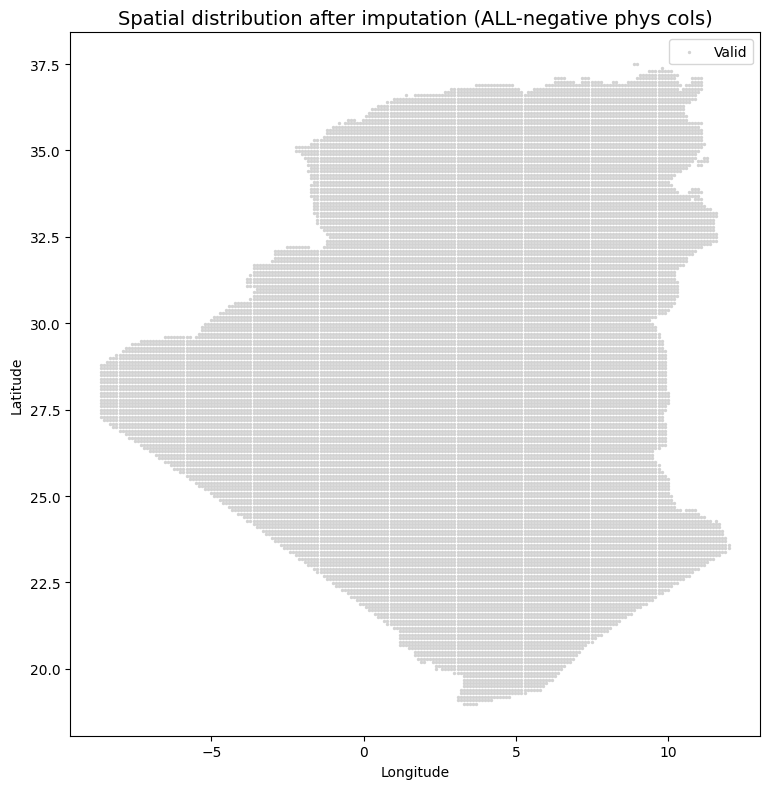

In [50]:
# Plot the map to verify ALL-negative phys_cols are now valid after imputation
# Ensure GeoDataFrame and CRS
if not isinstance(df_soil, gpd.GeoDataFrame) or 'geometry' not in df_soil.columns:
    df_soil = gpd.GeoDataFrame(
        df_soil,
        geometry=gpd.points_from_xy(df_soil['x'], df_soil['y']),
        crs="EPSG:4326"
    )
elif df_soil.crs is None:
    df_soil = df_soil.set_crs("EPSG:4326", allow_override=True)

# Use refreshed is_invalid (ALL-negative across physical columns)
invalid_mask = df_soil['is_invalid'].astype(bool)
valid_mask = ~invalid_mask

print(f"Invalid count after imputation (ALL-negative phys cols): {int(invalid_mask.sum())}")

fig, ax = plt.subplots(figsize=(10, 8))
# Plot valid points
if valid_mask.any():
    df_soil.loc[valid_mask].plot(ax=ax, color="lightgray", markersize=2, label="Valid")
# Plot remaining invalid points (if any)
if invalid_mask.any():
    df_soil.loc[invalid_mask].plot(ax=ax, color="blue", markersize=5, label="Invalid (All Negative)")

ax.set_title("Spatial distribution after imputation (ALL-negative phys cols)", fontsize=14)
ax.legend()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
savefig('soil_invalid_negative_spatial_distribution_after_imputation.png')
plt.show()

In [51]:
# detect outliers a second time
outliers = detect_outliers(df_soil, numeric_cols, multiplier=1.5, verbose=True)

Column: COARSE | Detected outliers: 28
Column: SAND | Detected outliers: 12
Column: SILT | Detected outliers: 0
Column: CLAY | Detected outliers: 53
Column: BULK | Detected outliers: 341
Column: REF_BULK | Detected outliers: 969
Column: ORG_CARBON | Detected outliers: 2897
Column: PH_WATER | Detected outliers: 272
Column: TOTAL_N | Detected outliers: 190
Column: CN_RATIO | Detected outliers: 1
Column: CEC_SOIL | Detected outliers: 53
Column: CEC_CLAY | Detected outliers: 0
Column: CEC_EFF | Detected outliers: 506
Column: TEB | Detected outliers: 506
Column: BSAT | Detected outliers: 11
Column: ALUM_SAT | Detected outliers: 28
Column: ESP | Detected outliers: 4095
Column: TCARBON_EQ | Detected outliers: 0
Column: GYPSUM | Detected outliers: 1182
Column: ELEC_COND | Detected outliers: 5973
Column: PH_WATER | Detected outliers: 272


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_qq_numeric_after_imputation.png


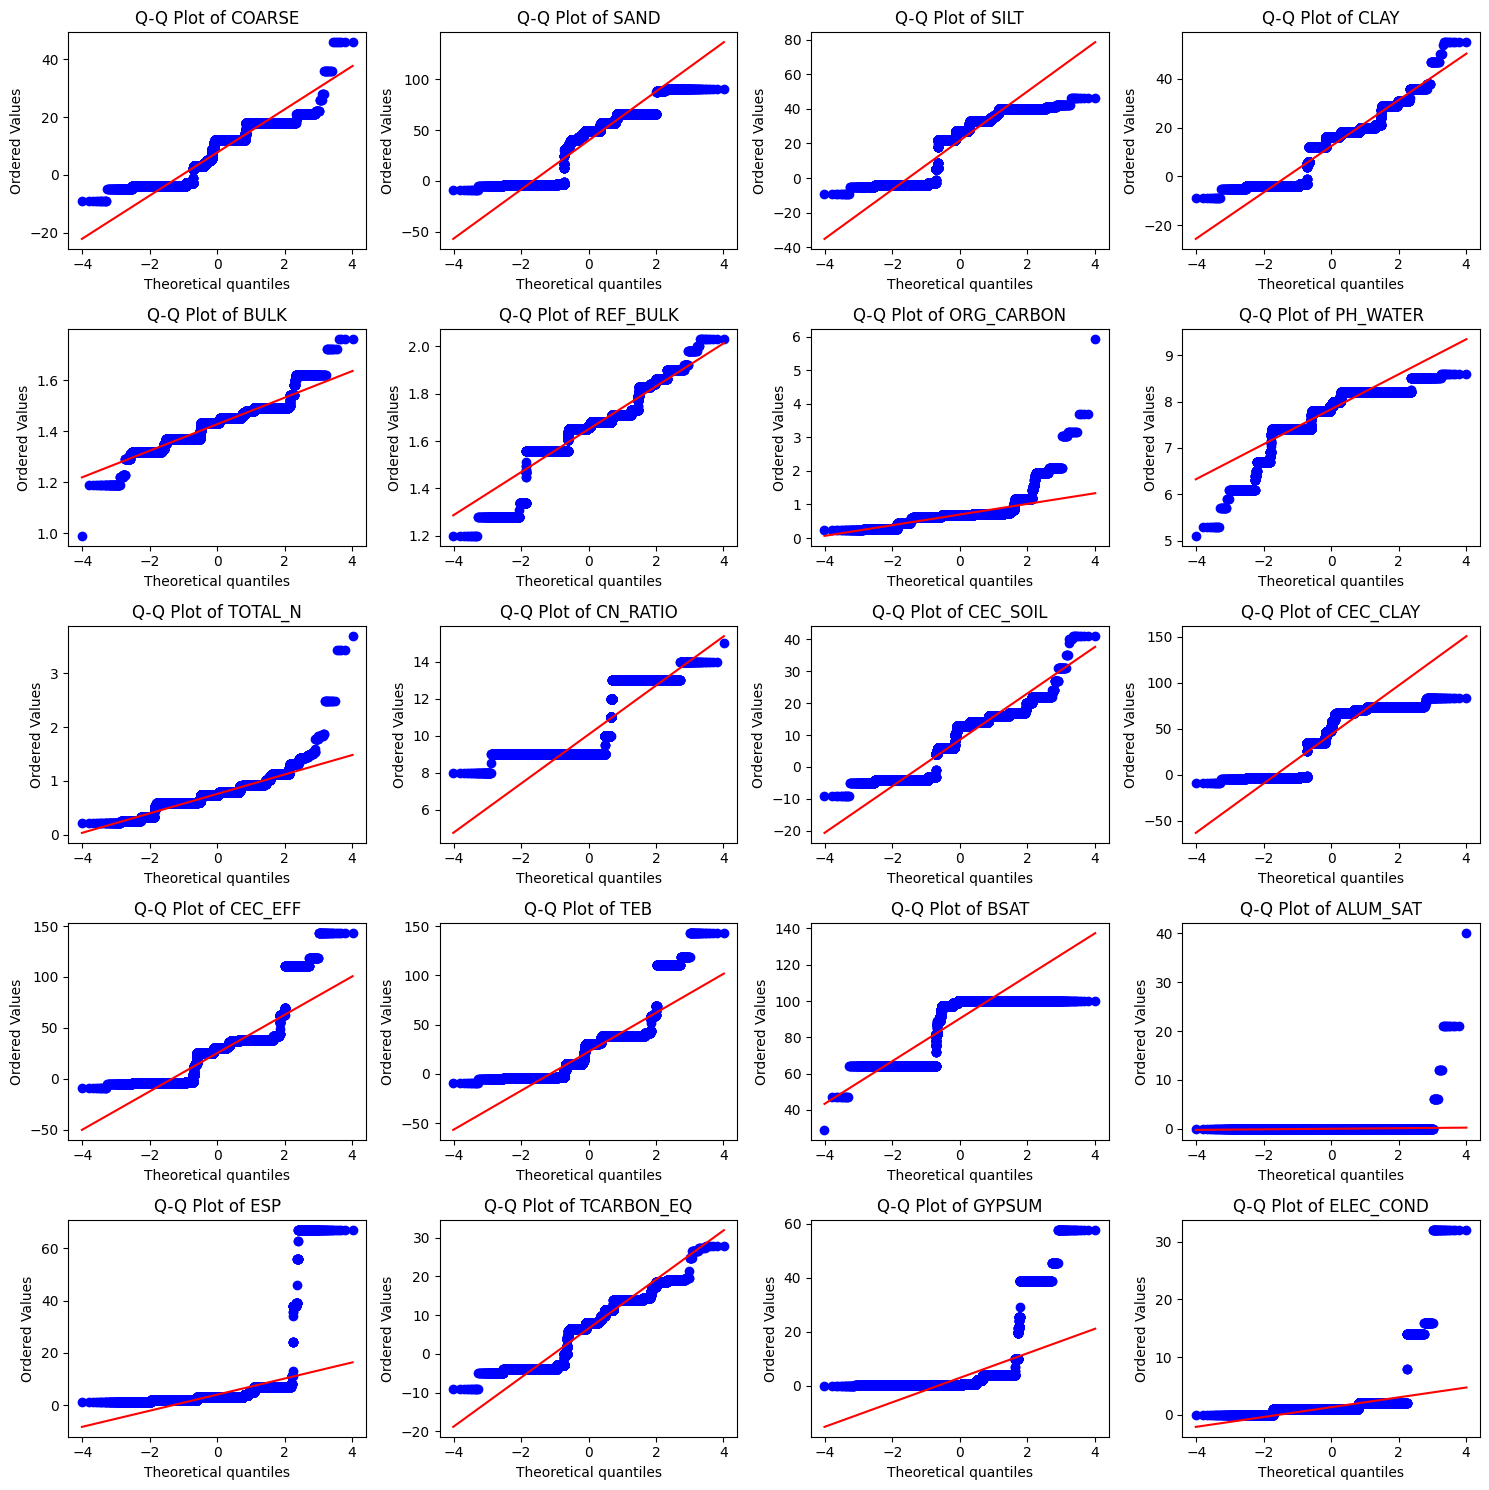

In [52]:
#quantile plot for numeric columns
plt.figure(figsize=(15, 15))

# use unique_cols (no duplicated columns) and the already computed n_rows_plot
for i, col in enumerate(unique_cols, 1):
    plt.subplot(n_rows_plot, 4, i)
    stats.probplot(df_soil[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")

plt.tight_layout()
savefig('soil_qq_numeric_after_imputation.png')
plt.show()


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_all_after_imputation.png


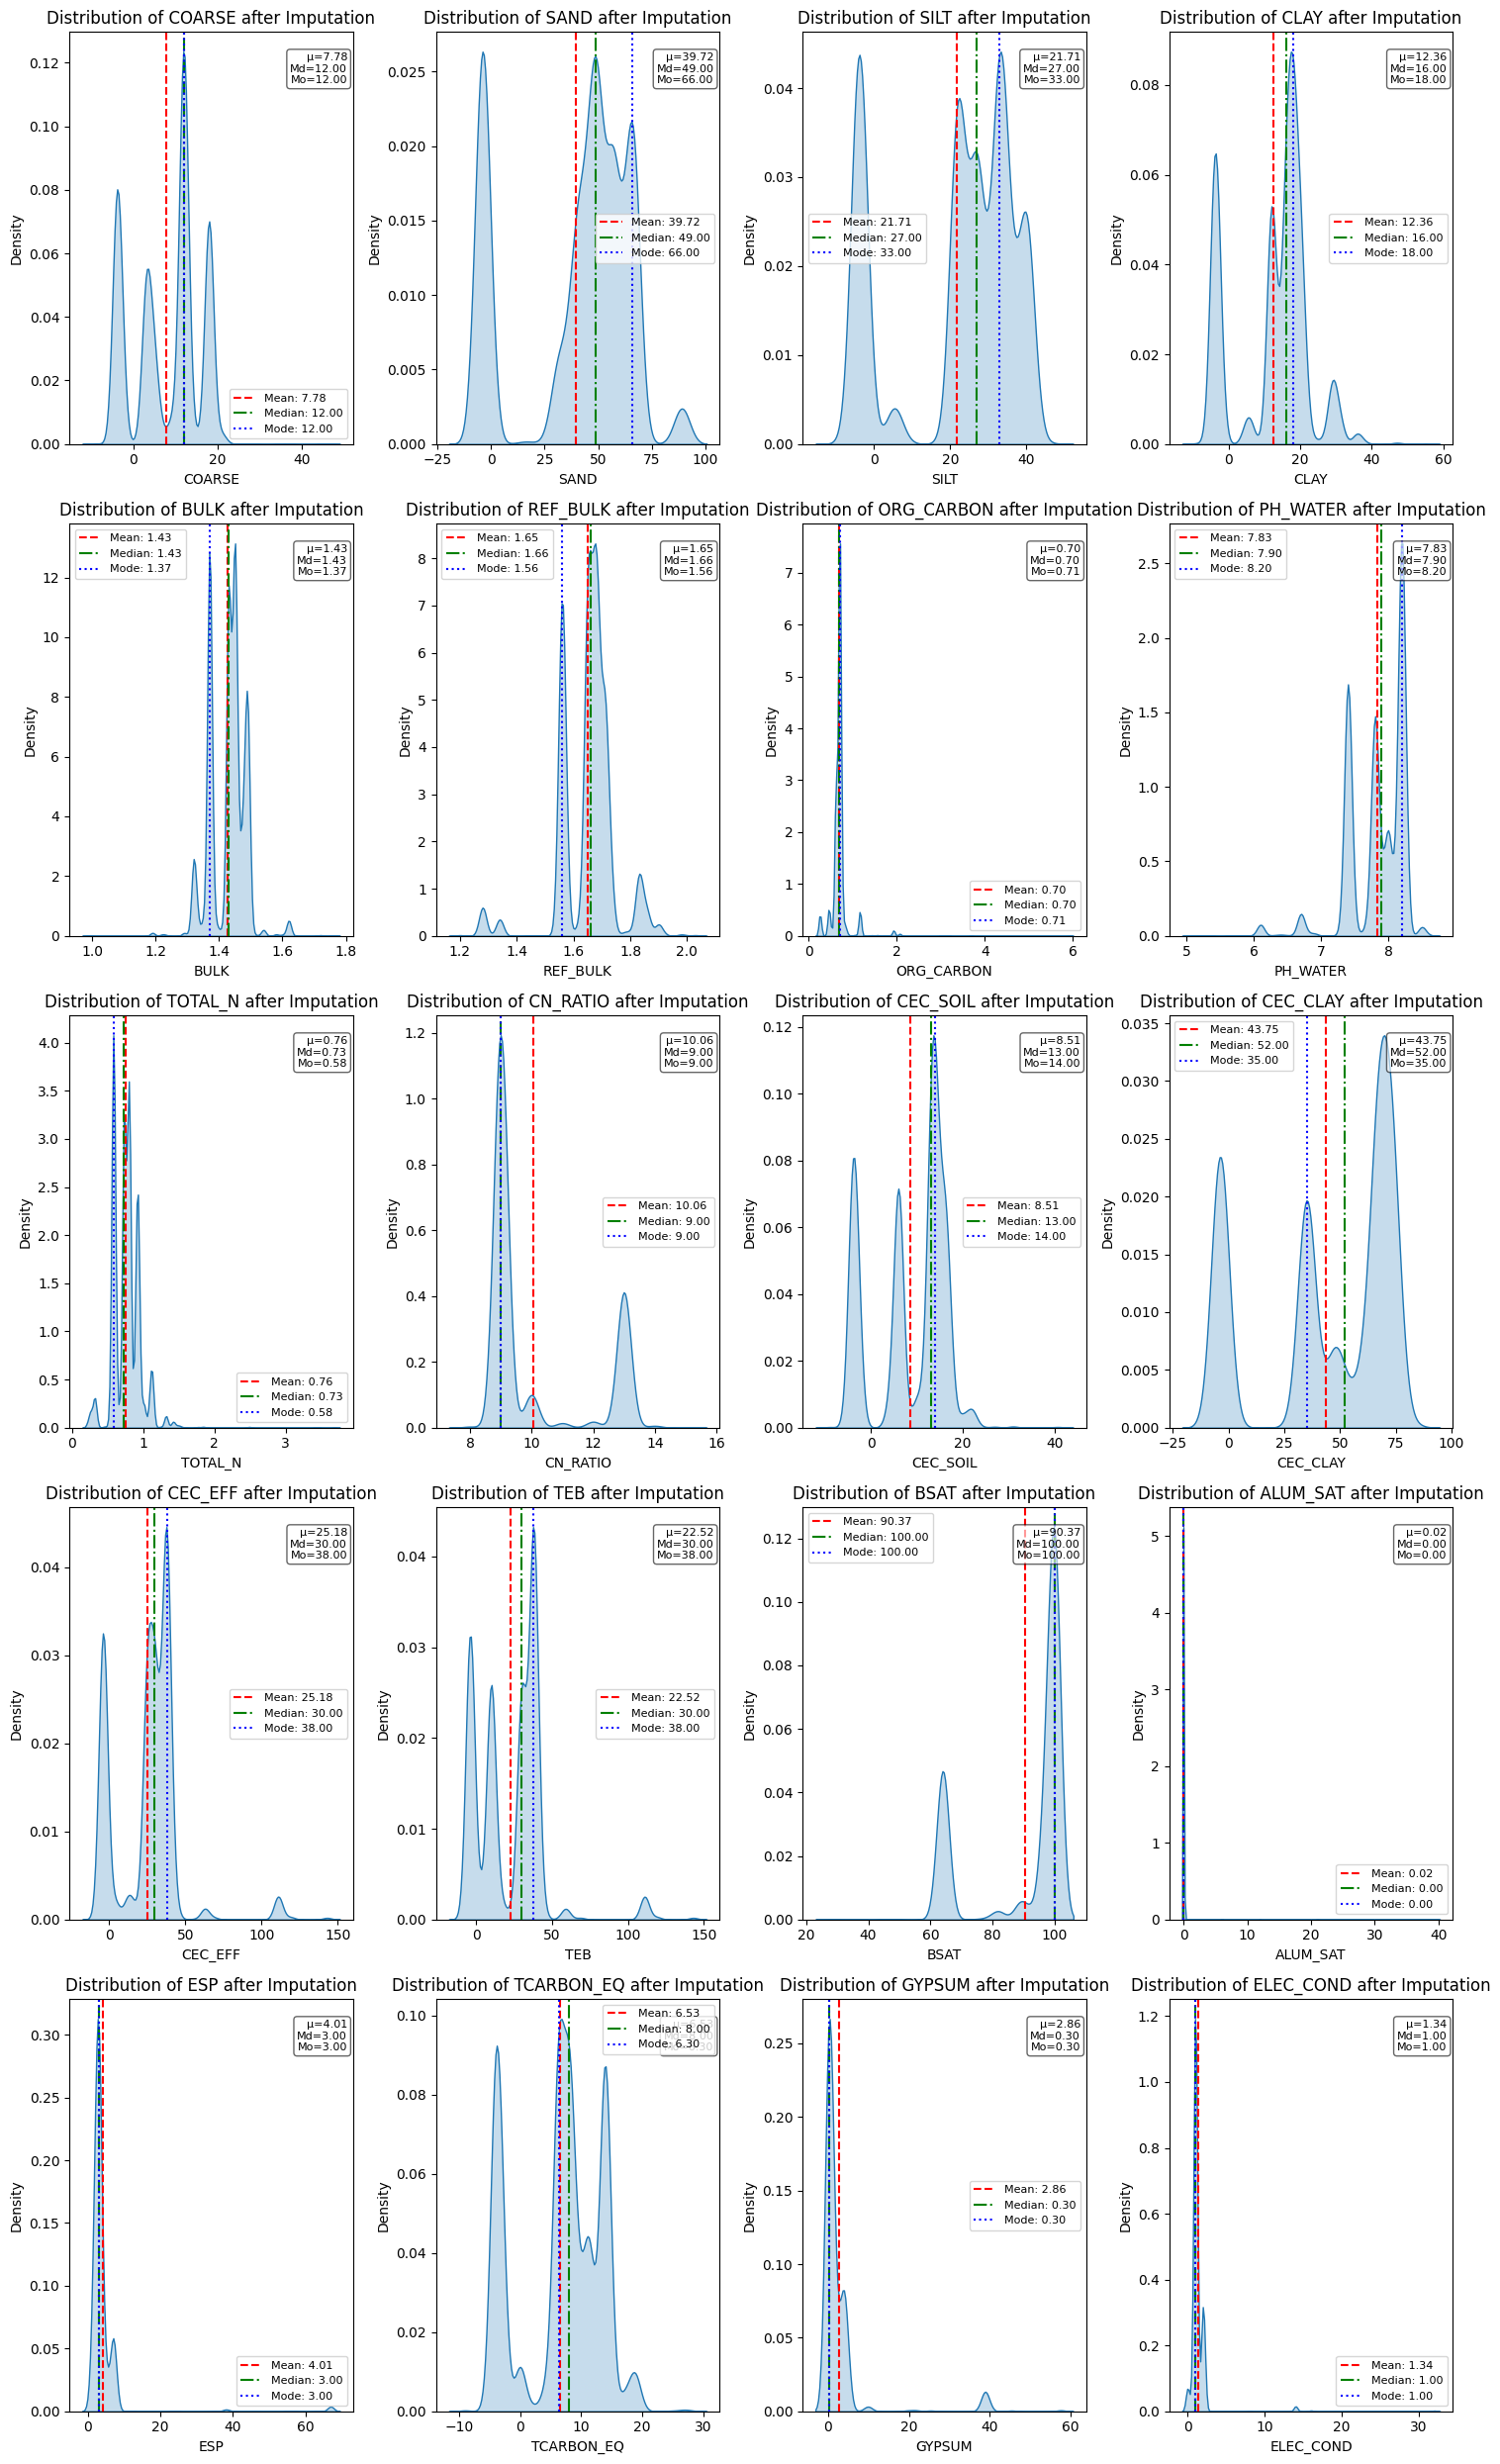

In [53]:
# distribution of numeric columns after imputation with mean/median/mode annotations
fig, axes = plt.subplots(n_rows_plot, 4, figsize=(15, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(unique_cols):
    ax = axes[i]
    data = df_soil[col].dropna()
    if data.empty:
        ax.text(0.5, 0.5, f"{col}\nNo data", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    sns.kdeplot(data, fill=True, ax=ax)
    mean_val, median_val, mode_val = df_soil[col].mean(), df_soil[col].median(), df_soil[col].mode().iloc[0]

    # vertical lines for stats
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=1.5, label=f"Median: {median_val:.2f}")
    ax.axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label=f"Mode: {mode_val:.2f}")

    # small text annotation inside plot (avoid overlap)
    ymax = ax.get_ylim()[1]
    ax.text(0.98, 0.95, f"μ={mean_val:.2f}\nMd={median_val:.2f}\nMo={mode_val:.2f}",
            ha='right', va='top', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.6))

    ax.set_title(f"Distribution of {col} after Imputation")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, wspace=0.30)
savefig('soil_kde_all_after_imputation.png')
plt.show()

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_maps_numeric_variation_after_invalid_imputation.png


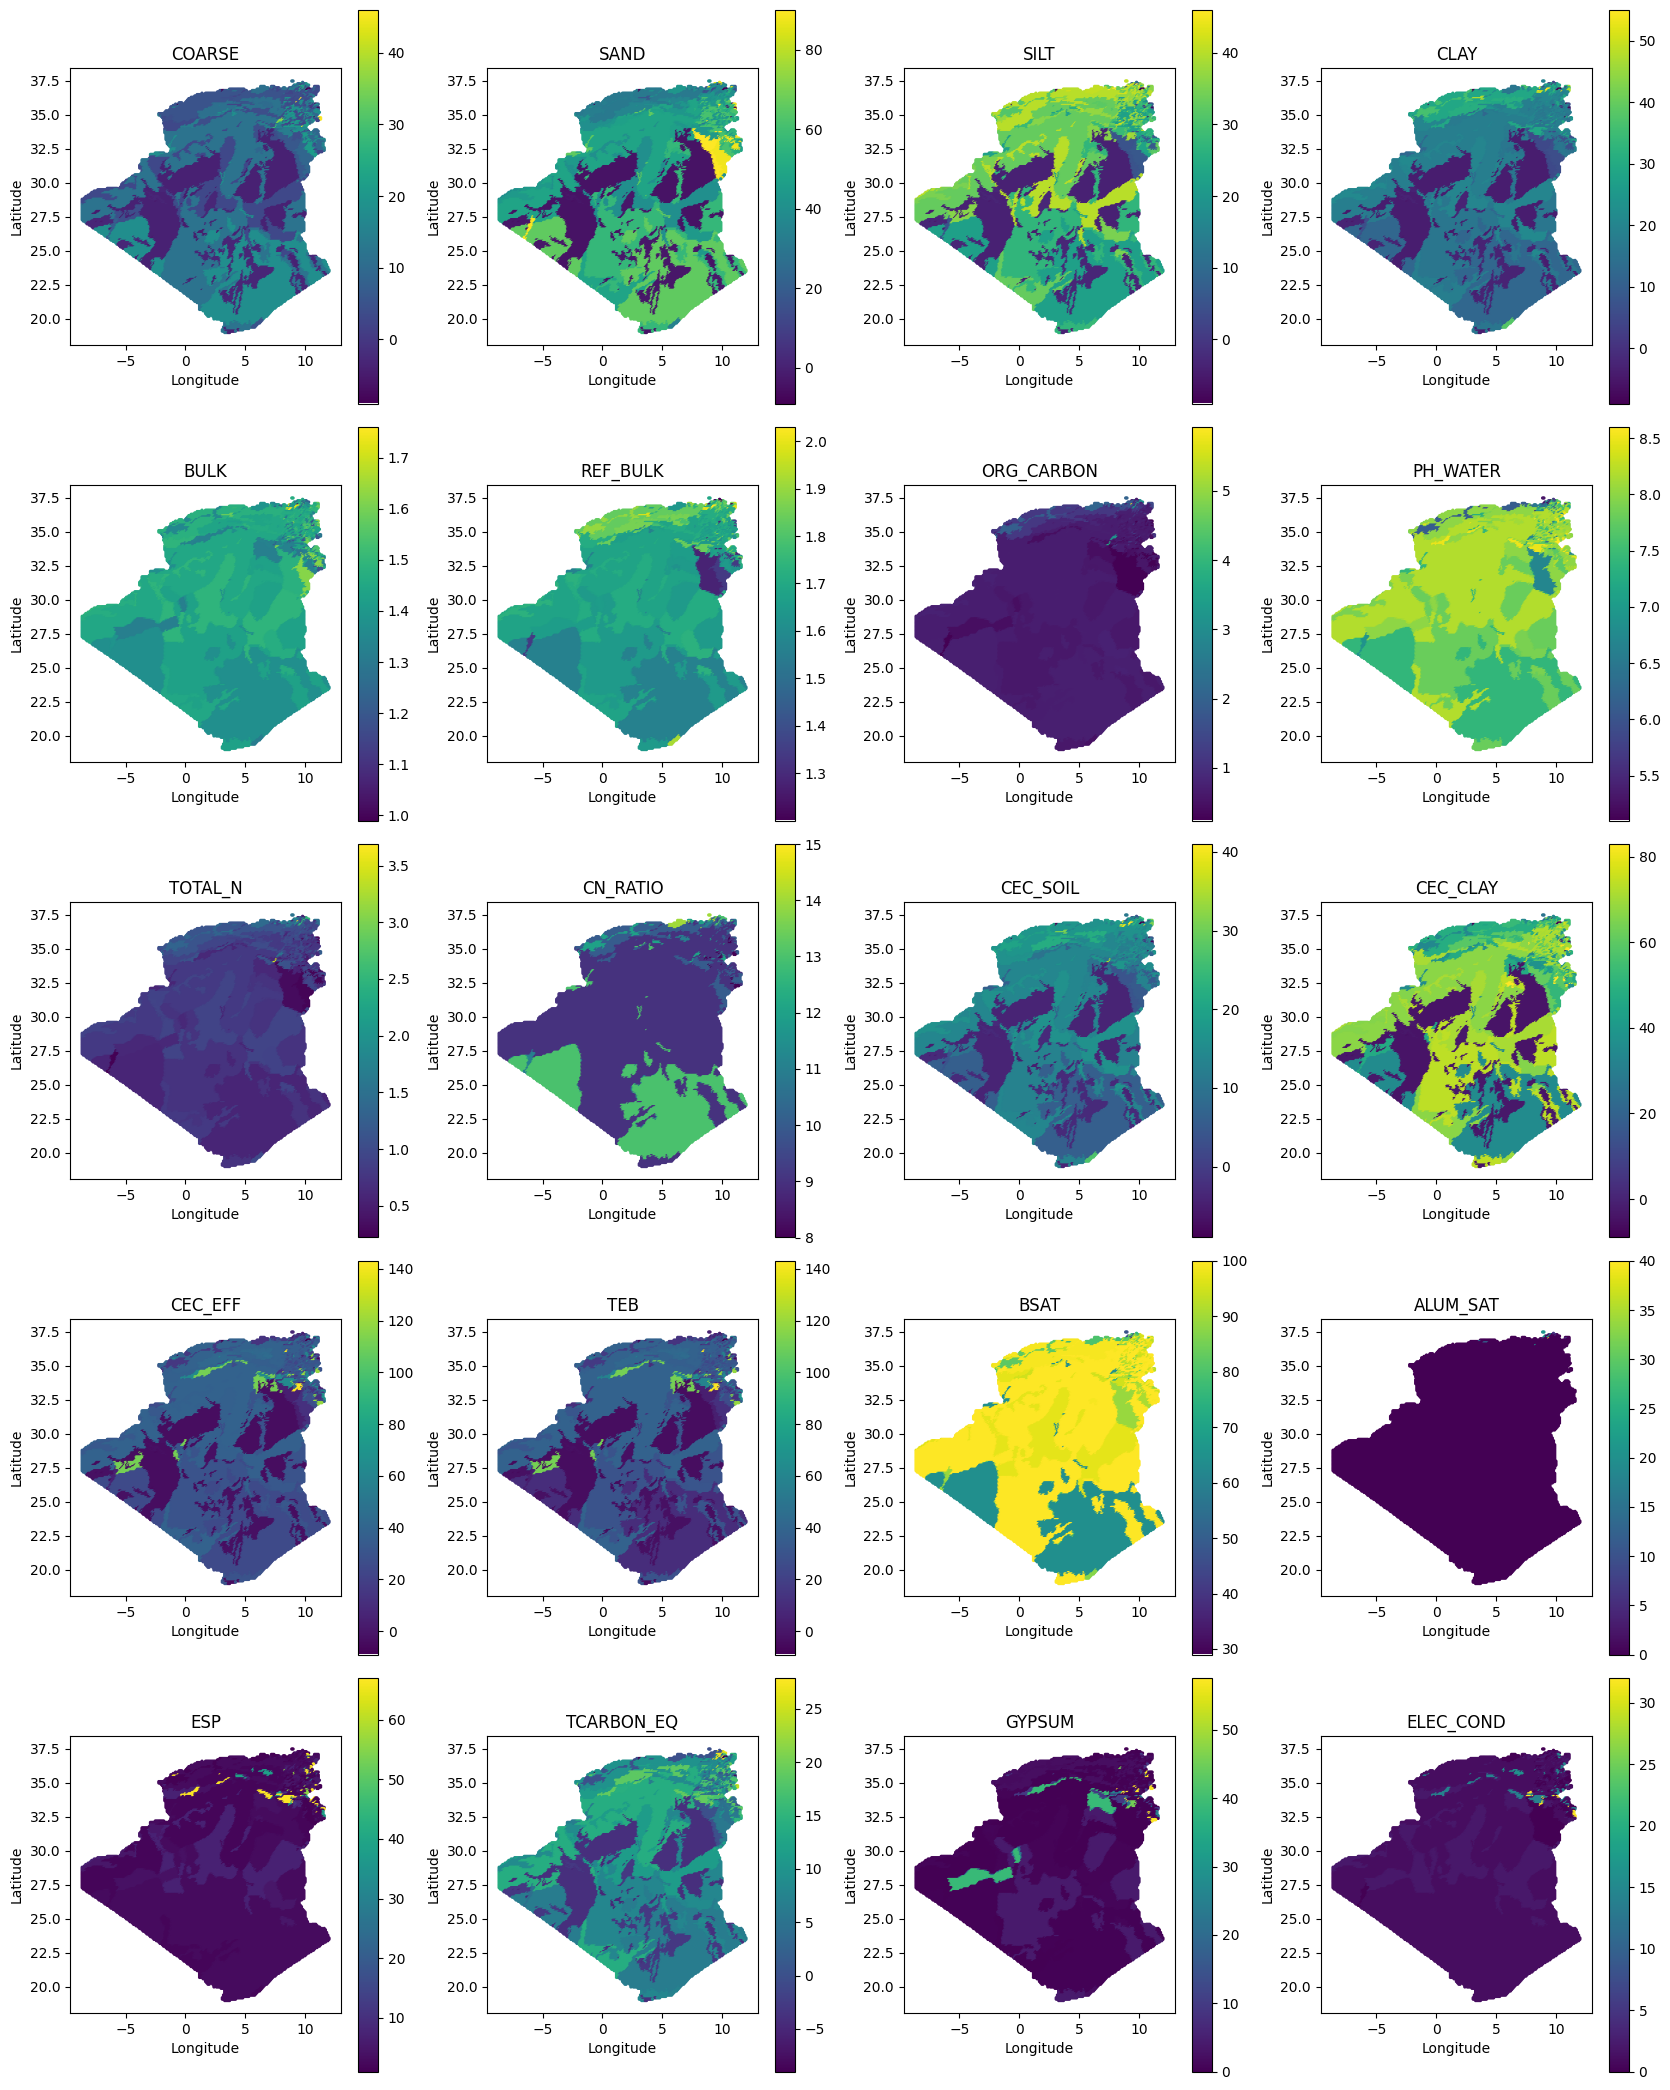

In [54]:
# Plot maps (subplots) showing spatial variation for each numeric column
# Ensure GeoDataFrame and CRS
if not isinstance(df_soil, gpd.GeoDataFrame) or 'geometry' not in df_soil.columns:
    df_soil = gpd.GeoDataFrame(
        df_soil,
        geometry=gpd.points_from_xy(df_soil['x'], df_soil['y']),
        crs="EPSG:4326"
    )
elif df_soil.crs is None:
    df_soil = df_soil.set_crs("EPSG:4326", allow_override=True)

# Deduplicate numeric_cols (PH_WATER is listed twice)
unique_numeric_cols = []
for c in numeric_cols:
    if c not in unique_numeric_cols and c in df_soil.columns:
        unique_numeric_cols.append(c)

n = len(unique_numeric_cols)
if n == 0:
    print("No numeric columns found to map.")
else:
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 4.2*nrows), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(unique_numeric_cols):
        ax = axes[i]
        series = df_soil[col]
        if series.dropna().empty:
            ax.text(0.5, 0.5, f"{col}\nNo data", ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        try:
            df_soil.plot(column=col, ax=ax, legend=True, cmap='viridis', markersize=2)
        except Exception as e:
            # Fallback: plot points without color if any issue
            df_soil.plot(ax=ax, color='gray', markersize=2)
            ax.text(0.5, 0.05, f"Failed to color by {col}: {e}", ha='center', va='bottom', transform=ax.transAxes, fontsize=8)
        ax.set_title(col)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # Hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    savefig('soil_maps_numeric_variation_after_invalid_imputation.png')
    plt.show()

In [55]:
#range values of columns: ESP GYPSUM and ELEC_COND
for col in ['ESP', 'GYPSUM', 'ELEC_COND']:
    if col in df_soil.columns:
        col_min = df_soil[col].min()
        col_max = df_soil[col].max()
        col_range = col_max - col_min
        print(f"{col} - Min: {col_min}, Max: {col_max}, Range: {col_range}")
    else:
        print(f"Column {col} not found in the dataset.")

ESP - Min: 1.0, Max: 67.0, Range: 66.0
GYPSUM - Min: 0.0, Max: 57.59999847412109, Range: 57.59999847412109
ELEC_COND - Min: 0.0, Max: 32.0, Range: 32.0


### **Data Reduction**

In [56]:
#pearson correlation function
def pearsonSpearman(df, col1, col2):
    correlation, p_value = pearsonr(df[col1].dropna(), df[col2].dropna())
    print(f"Pearson correlation between {col1} and {col2}: {correlation:.4f} (p-value: {p_value:.4e})")
    spearman_corr, spearman_p = stats.spearmanr(df[col1].dropna(), df[col2].dropna())
    print(f"Spearman correlation between {col1} and {col2}: {spearman_corr:.4f} (p-value: {spearman_p:.4f}) (p-value: {spearman_p:.4e})")

In [57]:
def corrPlot(df, col1, col2):
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Scatter plot
    axes[0].scatter(df[col1], df[col2], alpha=0.5, s=20, color='steelblue')
    axes[0].set_xlabel(f'{col1}')
    axes[0].set_ylabel(f'{col2}')
    axes[0].set_title(f'Scatter Plot: {col1} vs {col2}')
    axes[0].grid(True, alpha=0.3)

    # Add diagonal reference line
    min_val = min(df[col1].min(), df[col2].min())
    max_val = max(df[col1].max(), df[col2].max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
    axes[0].legend()

    # Right: Q-Q plot (comparing sorted quantiles of BULK vs REF_BULK)
    col1_sorted = np.sort(df[col1].dropna())
    col2_sorted = np.sort(df[col2].dropna())

    # Match lengths by using minimum length
    min_len = min(len(col1_sorted), len(col2_sorted))
    col1_sorted = col1_sorted[:min_len]
    col2_sorted = col2_sorted[:min_len]

    axes[1].scatter(col1_sorted, col2_sorted, alpha=0.5, s=20, color='coral')
    axes[1].plot([col1_sorted.min(), col1_sorted.max()], 
                [col2_sorted.min(), col2_sorted.max()], 
                'r--', linewidth=2, label='Perfect match')
    axes[1].set_xlabel(f'{col1} (sorted quantiles)')
    axes[1].set_ylabel(f'{col2} (sorted quantiles)')
    axes[1].set_title(f'Q-Q Plot: {col1} vs {col2}')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    savefig(f'soil_{col1}_vs_{col2}_scatter_qq.png')
    plt.show()

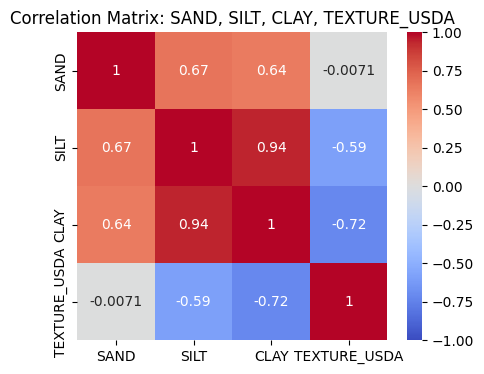

In [58]:


corr = df_soil[['SAND','SILT','CLAY','TEXTURE_USDA']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix: SAND, SILT, CLAY, TEXTURE_USDA")
plt.show()


In [59]:
def parallelCoordinatesPlot(df, col1, col2, col3, col4):
    subset = df[[col1, col2, col3, col4]].copy()
    subset = subset.dropna()

    # Choose grouping strategy:
    nunique = subset[col4].nunique()
    if nunique <= 10:
        # treat as categorical (e.g. TEXTURE_USDA classes)
        subset["group"] = subset[col4].astype(str)
    else:
        # try quantile bins, fallback to cut if edges are not unique
        try:
            subset["group"] = pd.qcut(subset[col4], 4, labels=["Low", "Med-Low", "Med-High", "High"], duplicates='drop')
            # if qcut collapsed to fewer bins (or returned NaN), fallback to cut
            if subset["group"].isnull().all() or subset["group"].nunique() < 2:
                subset["group"] = pd.cut(subset[col4], 4, labels=["Low", "Med-Low", "Med-High", "High"])
        except Exception:
            subset["group"] = pd.cut(subset[col4], 4, labels=["Low", "Med-Low", "Med-High", "High"])

    # scale the three numeric axes to [0,1] for comparable plotting
    num_cols = [col1, col2, col3]
    for c in num_cols:
        col_min = subset[c].min()
        col_max = subset[c].max()
        if col_max > col_min:
            subset[c] = (subset[c] - col_min) / (col_max - col_min)
        else:
            subset[c] = 0.0

    # prepare colors for the number of groups
    groups = subset["group"].astype(str).unique()
    colors = sns.color_palette("tab10", n_colors=len(groups))

    plt.figure(figsize=(10, 6))
    parallel_coordinates(subset, "group", color=colors)
    plt.title(f"Parallel Coordinates: {col1}, {col2}, {col3} grouped by {col4}")
    plt.ylabel("Scaled Values")
    plt.xlabel("Variables")
    plt.legend(title=str(col4), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    savefig(f'soil_parallel_coordinates_{col4}.png')
    plt.show()


In [60]:
#extract unique values of TEXTURE_USDA
unique_textures_usda = df_soil["TEXTURE_USDA"].unique()
unique_textures_soter = df_soil["TEXTURE_SOTER"].unique()
print(f"Unique values of TEXTURE_SOTER: {unique_textures_soter}")
print(f"Unique values of TEXTURE_USDA: {unique_textures_usda}")

Unique values of TEXTURE_SOTER: ['M' 'C' '-' 'F']
Unique values of TEXTURE_USDA: [ 9. 12.  5. 11.  3. 10.]


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_parallel_coordinates_texture.png


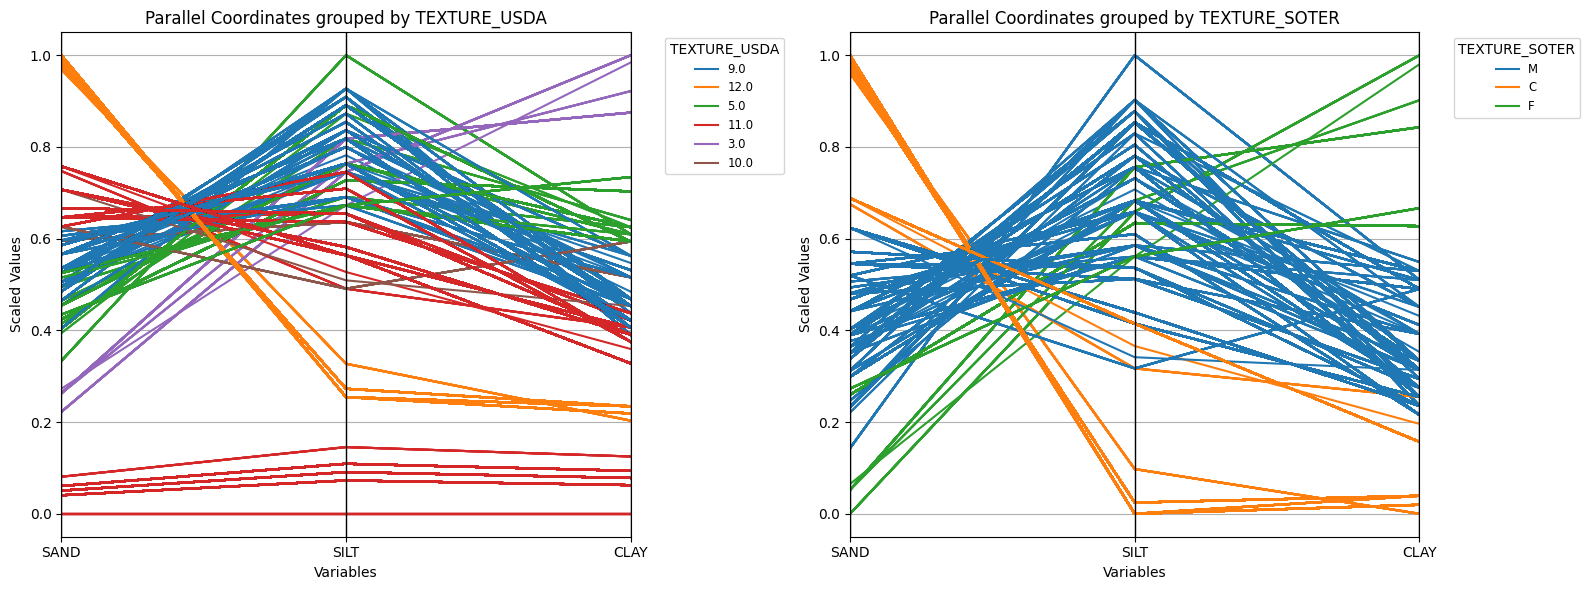

In [61]:

# One figure with two parallel-coordinate subplots (grouped by TEXTURE_USDA and TEXTURE_SOTER)

num_cols = ['SAND', 'SILT', 'CLAY']
group_cols = ['TEXTURE_USDA', 'TEXTURE_SOTER']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, gcol in zip(axes, group_cols):
    subset = df_soil[num_cols + [gcol]].copy()

    # Treat '-' as missing for TEXTURE_SOTER and coerce non-informative groups
    if subset[gcol].dtype == object:
        subset[gcol] = subset[gcol].replace('-', np.nan)

    subset = subset.dropna()
    if subset.empty:
        ax.text(0.5, 0.5, f"No data for {gcol}", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    # Grouping: categorical if few unique values, otherwise quantile bins
    nunique = subset[gcol].nunique()
    if nunique <= 10:
        subset['group'] = subset[gcol].astype(str)
    else:
        try:
            subset['group'] = pd.qcut(subset[gcol], 4, labels=["Low", "Med-Low", "Med-High", "High"], duplicates='drop')
            if subset['group'].isnull().all() or subset['group'].nunique() < 2:
                subset['group'] = pd.cut(subset[gcol], 4, labels=["Low", "Med-Low", "Med-High", "High"])
        except Exception:
            subset['group'] = pd.cut(subset[gcol], 4, labels=["Low", "Med-Low", "Med-High", "High"])

    # Scale numeric columns to [0,1]
    for c in num_cols:
        cmin, cmax = subset[c].min(), subset[c].max()
        subset[c] = (subset[c] - cmin) / (cmax - cmin) if cmax > cmin else 0.0

    groups = subset['group'].astype(str).unique()
    n_colors = len(groups)
    colors = sns.color_palette("tab10", n_colors=n_colors) if n_colors <= 10 else sns.color_palette("tab20", n_colors=n_colors)

    # Draw parallel coordinates on the provided axis
    parallel_coordinates(subset[num_cols + ['group']], 'group', color=colors, ax=ax)
    ax.set_title(f"Parallel Coordinates grouped by {gcol}")
    ax.set_ylabel("Scaled Values")
    ax.set_xlabel("Variables")
    ax.legend(title=str(gcol), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
savefig('soil_parallel_coordinates_texture.png')
plt.show()

Pearson correlation between ORG_CARBON_per_TOTAL_N and CN_RATIO: 0.9249 (p-value: 0.0000e+00)
Spearman correlation between ORG_CARBON_per_TOTAL_N and CN_RATIO: 0.7869 (p-value: 0.0000) (p-value: 0.0000e+00)
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_ORG_CARBON_per_TOTAL_N_vs_CN_RATIO_scatter_qq.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_ORG_CARBON_per_TOTAL_N_vs_CN_RATIO_scatter_qq.png


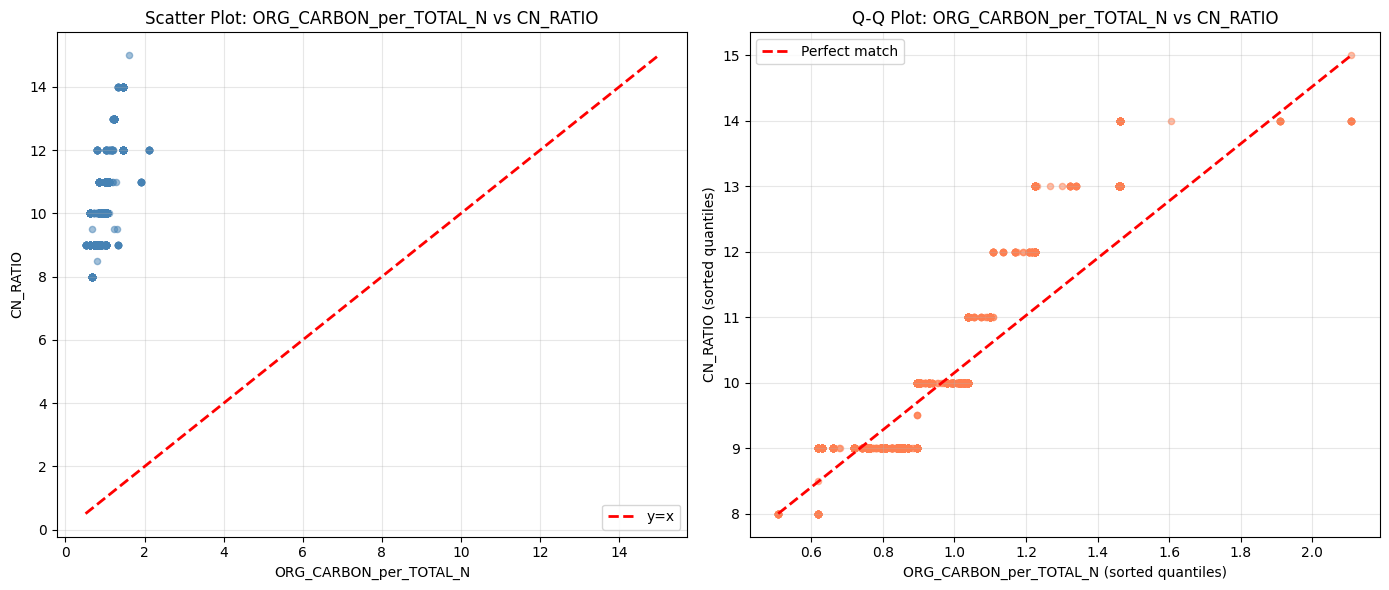

In [62]:
#test correla between ORGCARBONE/TOTAL_N and CN_RATIO
df_soil['ORG_CARBON_per_TOTAL_N'] = df_soil['ORG_CARBON'] / df_soil['TOTAL_N']
pearsonSpearman(df_soil, 'ORG_CARBON_per_TOTAL_N', 'CN_RATIO')
corrPlot(df_soil, 'ORG_CARBON_per_TOTAL_N', 'CN_RATIO')

Pearson correlation between CEC_SOIL_per_CLAY and CEC_CLAY: -0.3677 (p-value: 0.0000e+00)
Spearman correlation between CEC_SOIL_per_CLAY and CEC_CLAY: -0.1521 (p-value: 0.0000) (p-value: 1.8699e-120)
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_CEC_SOIL_per_CLAY_vs_CEC_CLAY_scatter_qq.png


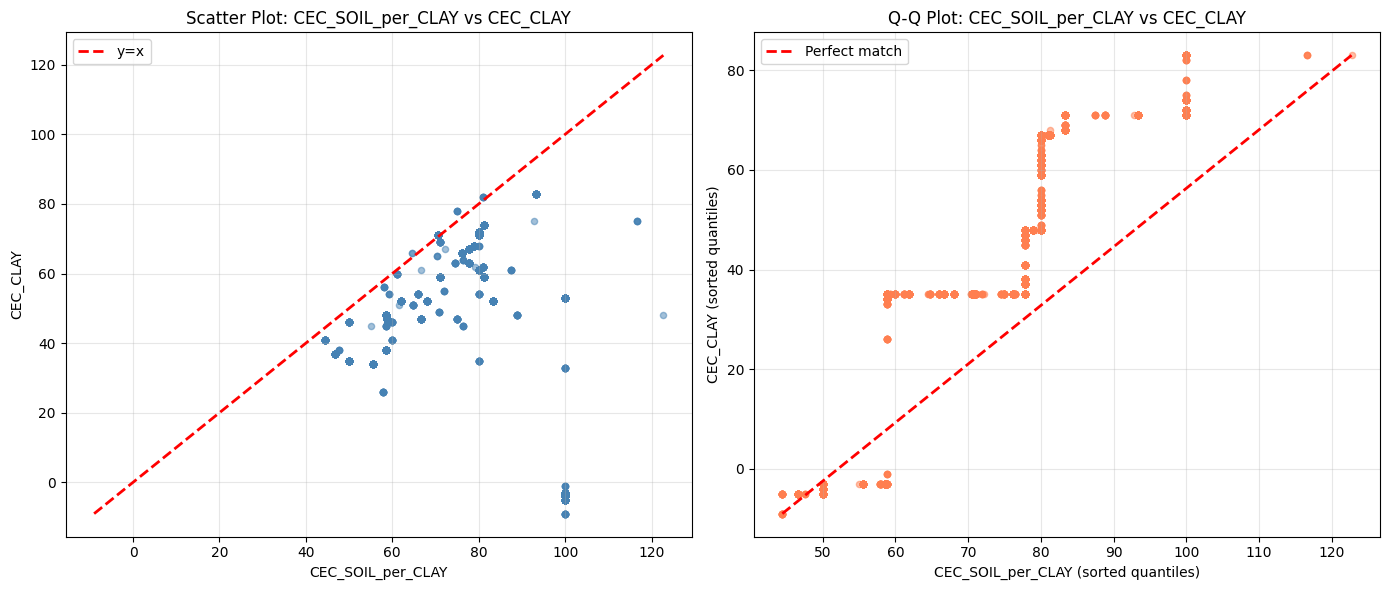

In [63]:
#test correla between CEC_SOIL/CLAY and CEC_CLAY
df_soil['CEC_SOIL_per_CLAY'] = (df_soil['CEC_SOIL'] / df_soil['CLAY'])*100
pearsonSpearman(df_soil, 'CEC_SOIL_per_CLAY', 'CEC_CLAY')
corrPlot(df_soil, 'CEC_SOIL_per_CLAY', 'CEC_CLAY')

Pearson correlation between TEB_per_CEC_EFF and BSAT: 0.8178 (p-value: 0.0000e+00)
Spearman correlation between TEB_per_CEC_EFF and BSAT: 0.4329 (p-value: 0.0000) (p-value: 0.0000e+00)
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_TEB_per_CEC_EFF_vs_BSAT_scatter_qq.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_TEB_per_CEC_EFF_vs_BSAT_scatter_qq.png


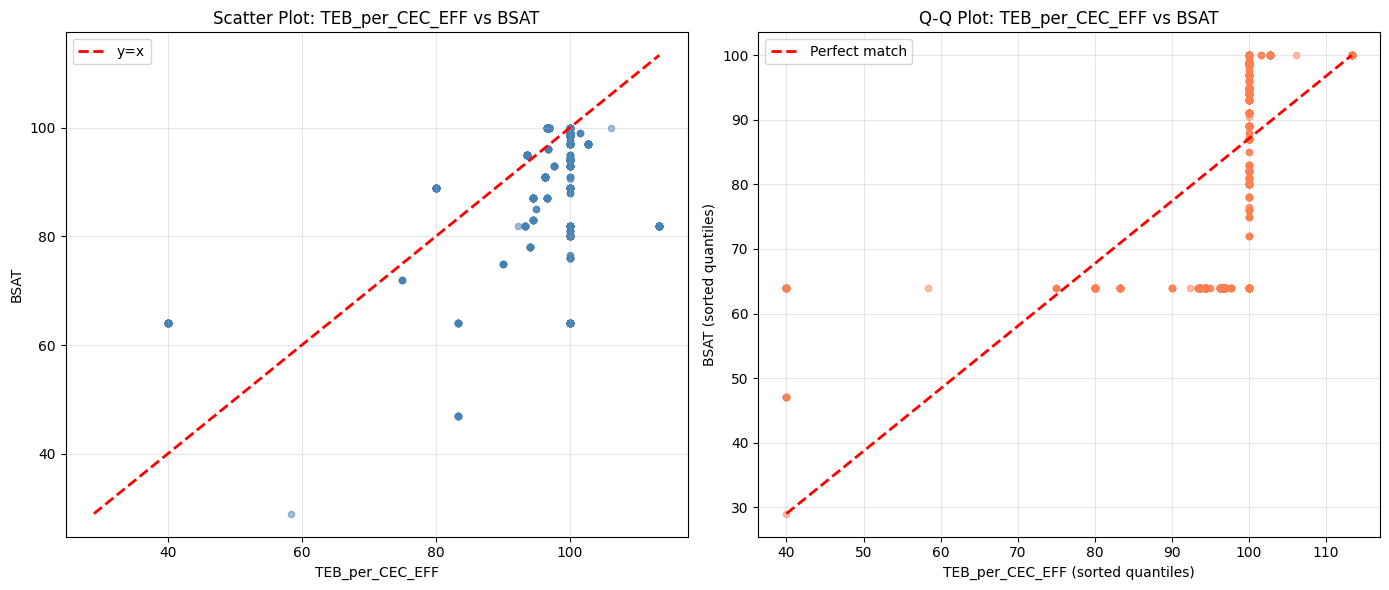

In [64]:
# test correla between BSAT = (TEB / CEC_EFF) × 100
df_soil['TEB_per_CEC_EFF'] = (df_soil['TEB'] / df_soil['CEC_EFF']) * 100
pearsonSpearman(df_soil, 'TEB_per_CEC_EFF', 'BSAT')
corrPlot(df_soil, 'TEB_per_CEC_EFF', 'BSAT')

In [65]:
df_soil.columns

Index(['y', 'x', 'HWSD2_SMU_ID', 'COARSE', 'SAND', 'SILT', 'CLAY',
       'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON',
       'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF',
       'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND',
       'geometry', 'is_invalid', 'ORG_CARBON_per_TOTAL_N', 'CEC_SOIL_per_CLAY',
       'TEB_per_CEC_EFF'],
      dtype='object')

In [66]:
columns_to_save = ['y', 'x', 'HWSD2_SMU_ID', 'COARSE', 'SAND', 'SILT', 'CLAY',
        'BULK', 'REF_BULK', 'ORG_CARBON',
       'PH_WATER', 'TOTAL_N', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF',
       'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND',
       ]

In [67]:
df_soil=df_soil[columns_to_save]


In [68]:
df_soil.shape

(23262, 22)

### **Normalisation**

Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_numeric_4perrow.png


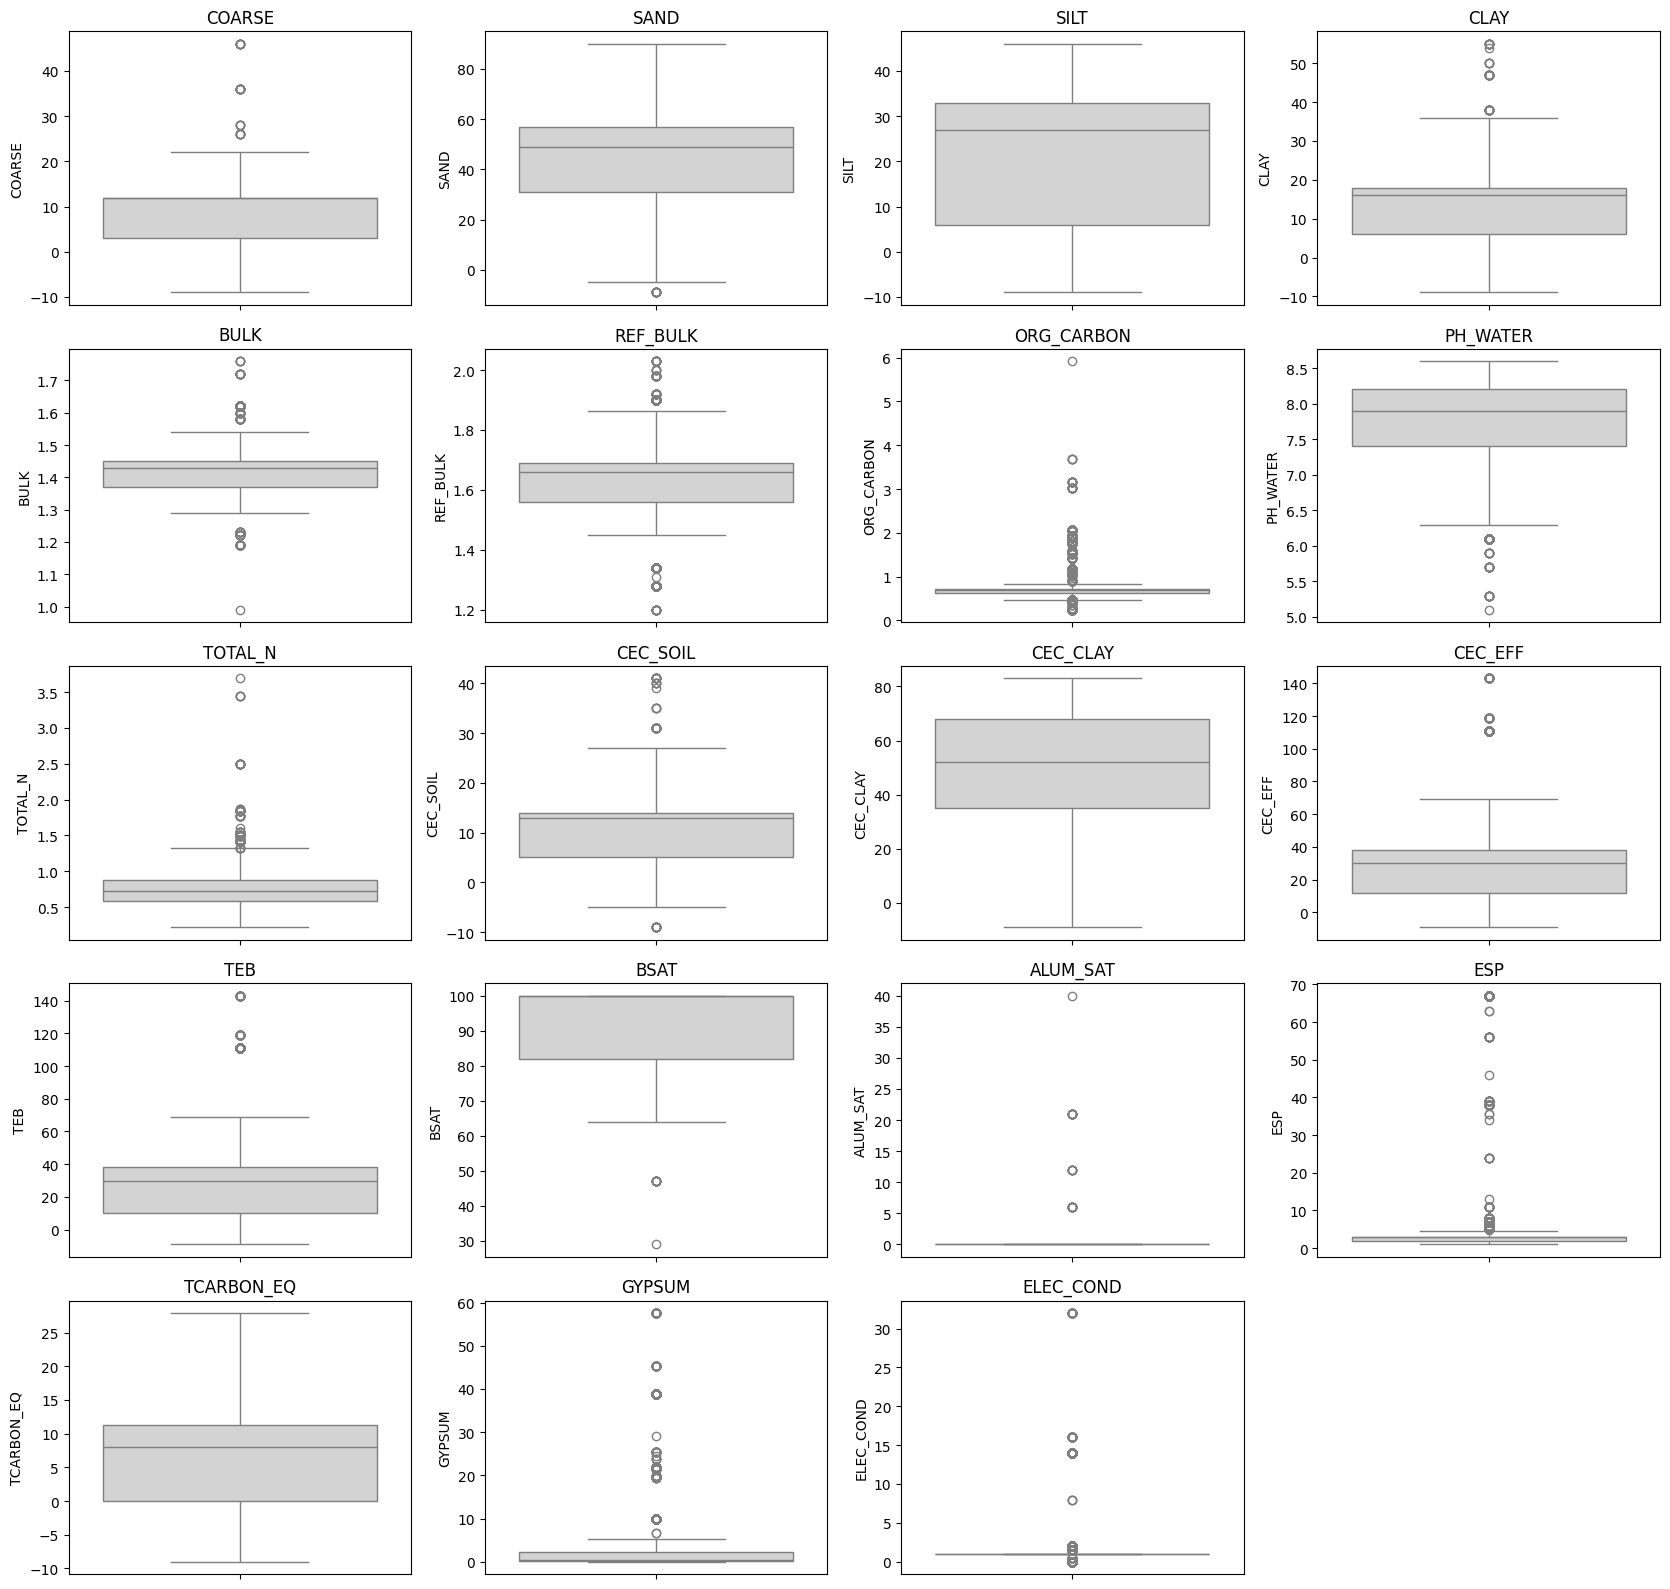

In [69]:
# Box plots for numeric columns excluding 'CN_RATIO' — 4 columns per row
# Deduplicate numeric_cols and remove CN_RATIO
new_numeric_cols = []
for c in numeric_cols:
    if c not in new_numeric_cols and c in df_soil.columns:
        new_numeric_cols.append(c)

plot_cols = [c for c in new_numeric_cols if c != 'CN_RATIO']
if len(plot_cols) == 0:
    print('No numeric columns available for boxplots.')
else:
    n = len(plot_cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), squeeze=False)
    axes_flat = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes_flat[i]
        try:
            sns.boxplot(y=df_soil[col], ax=ax, color='lightgray')
        except Exception:
            # fallback to matplotlib boxplot on numeric data
            data = df_soil[col].dropna().values
            if data.size:
                ax.boxplot(data, vert=True)
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_axis_off()
                continue
        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel(col)

    # Hide unused subplots
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    savefig('soil_boxplots_numeric_4perrow.png')
    plt.show()

In [70]:
#detect outliers 
outliers = detect_outliers(df_soil, plot_cols, multiplier=1.5, verbose=True)


Column: COARSE | Detected outliers: 28
Column: SAND | Detected outliers: 12
Column: SILT | Detected outliers: 0
Column: CLAY | Detected outliers: 53
Column: BULK | Detected outliers: 341
Column: REF_BULK | Detected outliers: 969
Column: ORG_CARBON | Detected outliers: 2897
Column: PH_WATER | Detected outliers: 272
Column: TOTAL_N | Detected outliers: 190
Column: CEC_SOIL | Detected outliers: 53
Column: CEC_CLAY | Detected outliers: 0
Column: CEC_EFF | Detected outliers: 506
Column: TEB | Detected outliers: 506
Column: BSAT | Detected outliers: 11
Column: ALUM_SAT | Detected outliers: 28
Column: ESP | Detected outliers: 4095
Column: TCARBON_EQ | Detected outliers: 0
Column: GYPSUM | Detected outliers: 1182
Column: ELEC_COND | Detected outliers: 5973


In [71]:
print(df_soil[new_numeric_cols].skew().sort_values())

PH_WATER      -1.454849
BSAT          -1.139070
REF_BULK      -0.954606
SILT          -0.718691
SAND          -0.682355
CEC_CLAY      -0.633284
CEC_SOIL      -0.475228
TCARBON_EQ    -0.378905
CLAY          -0.377868
COARSE        -0.205938
BULK          -0.083371
CEC_EFF        1.133127
TEB            1.314602
TOTAL_N        1.440030
GYPSUM         4.444313
ORG_CARBON     4.814376
ESP            8.542123
ELEC_COND     10.134515
ALUM_SAT      41.638225
dtype: float64


In [72]:
print(df_soil[new_numeric_cols].kurtosis().sort_values())

CEC_CLAY        -1.128678
COARSE          -1.067163
SILT            -0.955310
TCARBON_EQ      -0.893243
CEC_SOIL        -0.877142
SAND            -0.769555
BSAT            -0.598248
CLAY            -0.382028
BULK             1.826310
PH_WATER         3.279856
REF_BULK         4.006554
TEB              4.411336
CEC_EFF          4.897264
TOTAL_N         13.860733
GYPSUM          19.443999
ORG_CARBON      46.667879
ESP             77.474868
ELEC_COND      129.243496
ALUM_SAT      2039.828452
dtype: float64


In [73]:
# Normalization of soil properties according to property-specific methods
# Create a copy to preserve original values
df_soil_normalized = df_soil.copy()

# Small constant to avoid log(0)
EPSILON = 1e-6

In [74]:
# 1) Texture (composition): Min-Max (0-1) scaling
texture_cols = ['COARSE', 'SAND', 'SILT', 'CLAY']
for col in texture_cols:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")


COARSE: Min-Max scaling applied
SAND: Min-Max scaling applied
SILT: Min-Max scaling applied
CLAY: Min-Max scaling applied


In [75]:
# 2) Density & pH: Robust for densities, Min-Max for pH
# Robust scaling: (x - median) / IQR
for col in ['BULK', 'REF_BULK']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

# Min-Max for pH
if 'PH_WATER' in df_soil_normalized.columns:
    col_min = df_soil_normalized['PH_WATER'].min()
    col_max = df_soil_normalized['PH_WATER'].max()
    if col_max > col_min:
        df_soil_normalized['PH_WATER'] = (df_soil_normalized['PH_WATER'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['PH_WATER'] = 0.0
    print("PH_WATER: Min-Max scaling applied")


BULK: Robust scaling applied
REF_BULK: Robust scaling applied
PH_WATER: Min-Max scaling applied


In [76]:
# 3) Organic matter & nutrients
# Log + Robust for ORG_CARBON
if 'ORG_CARBON' in df_soil_normalized.columns:
    # treat non-positive / sentinel values as missing before log
    oc = df_soil_normalized['ORG_CARBON'].copy().astype(float)
    oc.loc[oc <= 0] = np.nan

    # log transform (safe with EPSILON)
    oc = np.log(oc + EPSILON)

    # robust scaling: (x - median) / IQR
    q1 = oc.quantile(0.25)
    q3 = oc.quantile(0.75)
    median = oc.median()
    iqr = q3 - q1
    if iqr > 0:
        oc = (oc - median) / iqr
    else:
        oc = oc - median

    # fill remaining NaNs with median of transformed values (robust fallback)
    oc = oc.fillna(oc.median())

    df_soil_normalized['ORG_CARBON'] = oc
    print("ORG_CARBON: Log + Robust scaling applied")

# Log for TOTAL_N (then standard scale)
if 'TOTAL_N' in df_soil_normalized.columns:
    df_soil_normalized['TOTAL_N'] = np.log(df_soil_normalized['TOTAL_N'] + EPSILON)
    mean_val = df_soil_normalized['TOTAL_N'].mean()
    std_val = df_soil_normalized['TOTAL_N'].std()
    if std_val > 0:
        df_soil_normalized['TOTAL_N'] = (df_soil_normalized['TOTAL_N'] - mean_val) / std_val
    else:
        df_soil_normalized['TOTAL_N'] = 0.0
    print("TOTAL_N: Log + Standard scaling applied")

# Min-Max for TCARBON_EQ
if 'TCARBON_EQ' in df_soil_normalized.columns:
    col_min = df_soil_normalized['TCARBON_EQ'].min()
    col_max = df_soil_normalized['TCARBON_EQ'].max()
    if col_max > col_min:
        df_soil_normalized['TCARBON_EQ'] = (df_soil_normalized['TCARBON_EQ'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['TCARBON_EQ'] = 0.0
    print("TCARBON_EQ: Min-Max scaling applied")


ORG_CARBON: Log + Robust scaling applied
TOTAL_N: Log + Standard scaling applied
TCARBON_EQ: Min-Max scaling applied


In [77]:
# 4) Cation exchange & fertility: Robust (CEC_SOIL, CEC_EFF,  TEB), Min-Max (CEC_CLAY, BSAT)
for col in ['CEC_SOIL', 'CEC_EFF', 'TEB']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

for col in ['CEC_CLAY', 'BSAT']:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")

CEC_SOIL: Robust scaling applied
CEC_EFF: Robust scaling applied
TEB: Robust scaling applied
CEC_CLAY: Min-Max scaling applied
BSAT: Min-Max scaling applied


In [78]:
# 5) Salinity & saturation: Log + Robust Scaling
for col in ['ALUM_SAT', 'ESP', 'GYPSUM', 'ELEC_COND']:
    if col in df_soil_normalized.columns:
        df_soil_normalized[col] = np.log(df_soil_normalized[col] + EPSILON)
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Log + Robust scaling applied")


ALUM_SAT: Log + Robust scaling applied
ESP: Log + Robust scaling applied
GYPSUM: Log + Robust scaling applied
ELEC_COND: Log + Robust scaling applied


In [79]:
print("\nAll normalization transformations completed")
print(f"Original shape: {df_soil.shape}")
print(f"Normalized shape: {df_soil_normalized.shape}")



All normalization transformations completed
Original shape: (23262, 22)
Normalized shape: (23262, 22)


Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_normalization_comparison.png


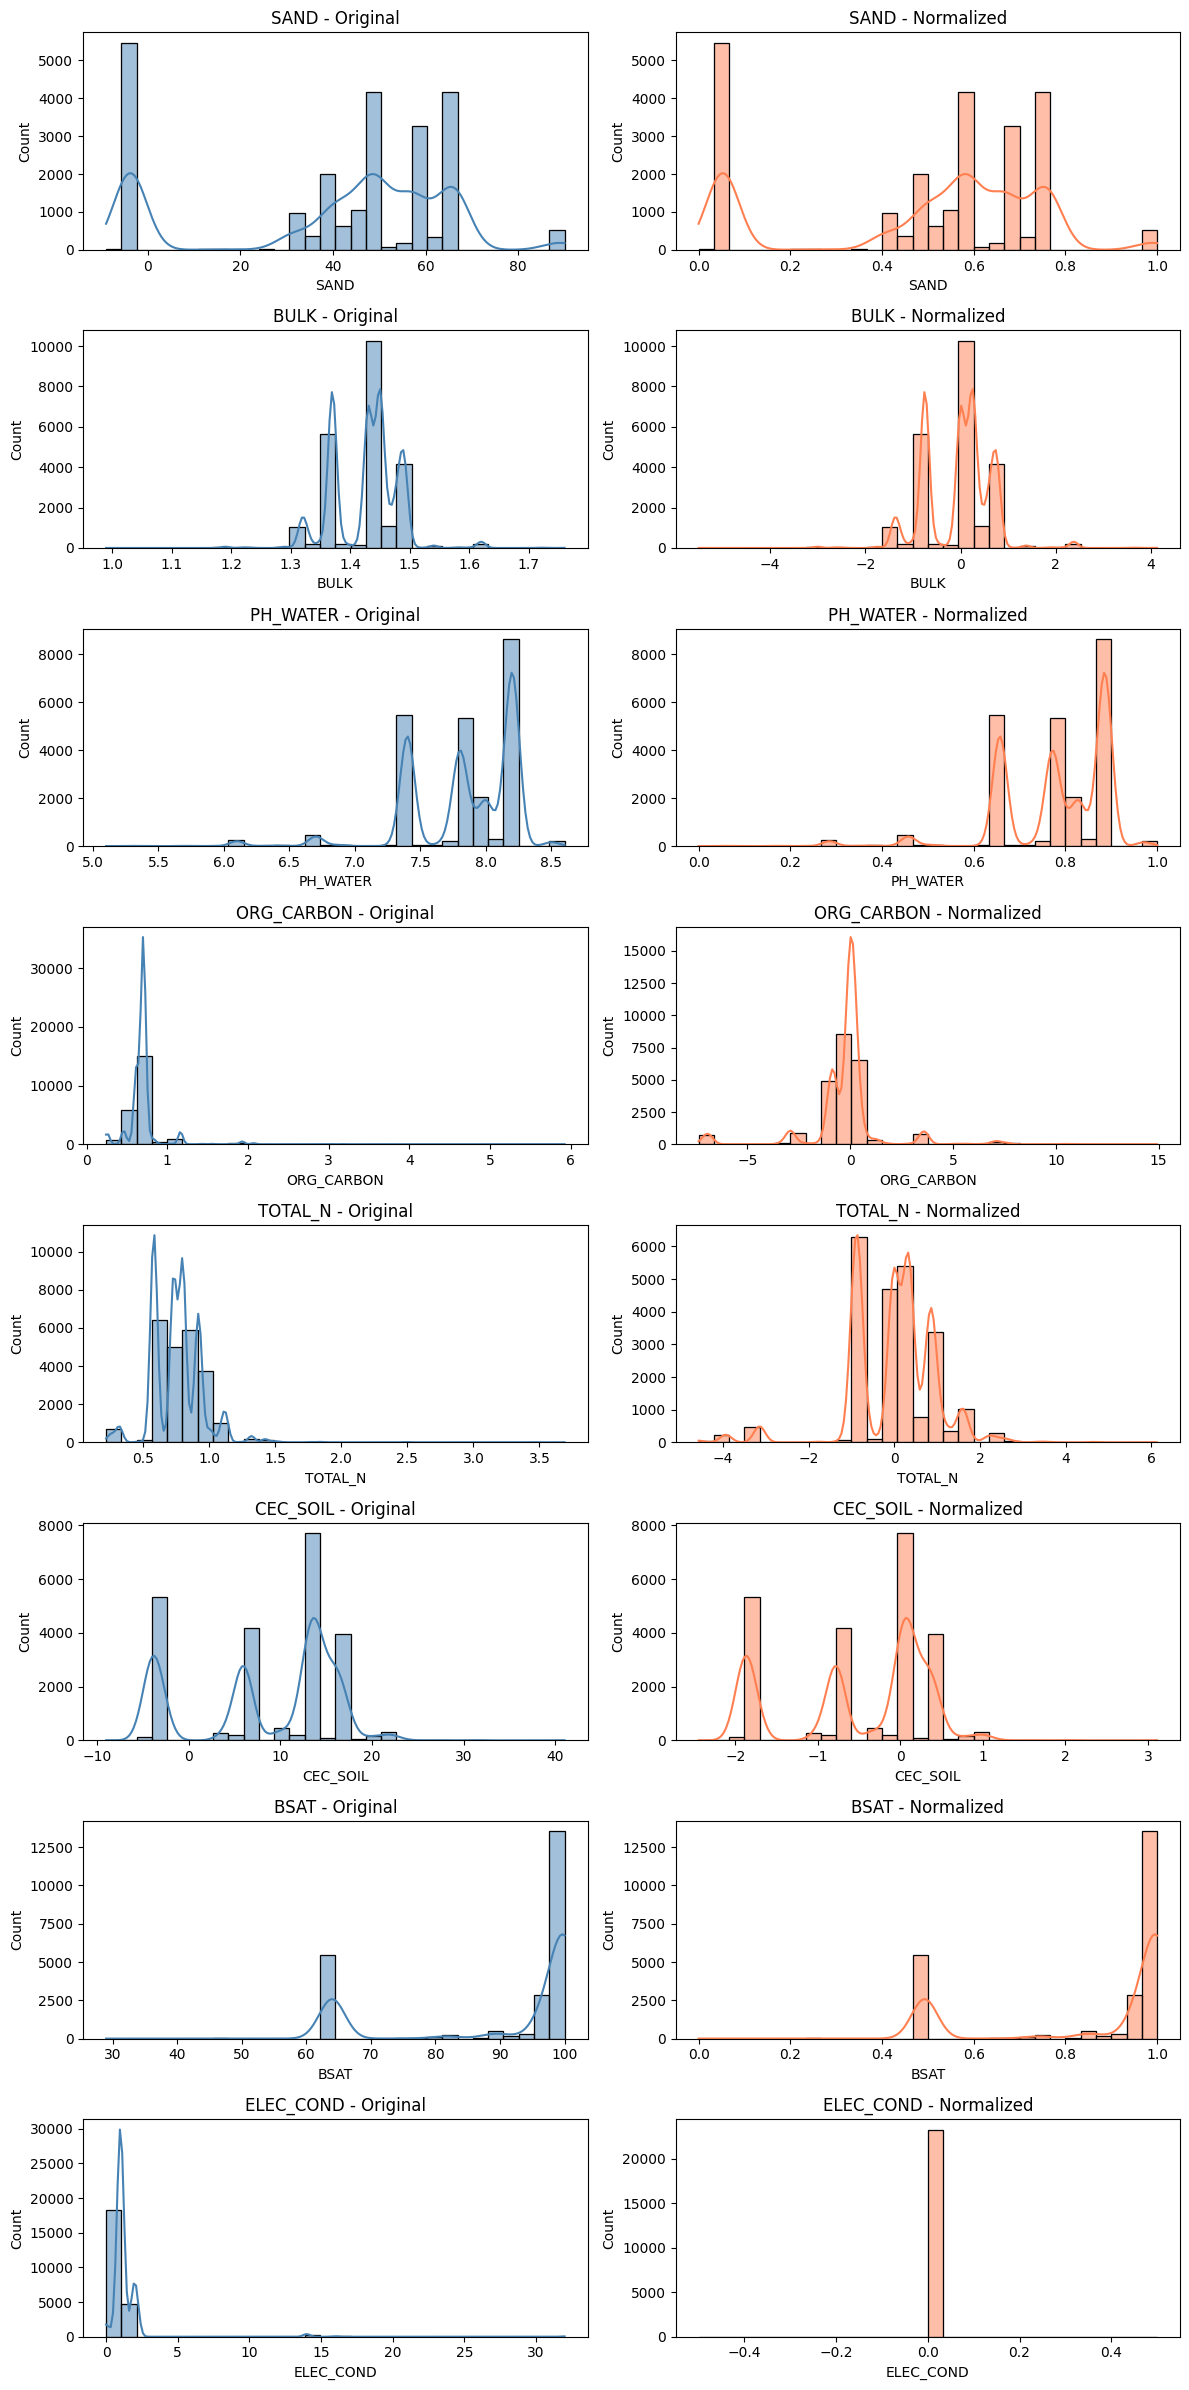

In [80]:
# Compare distributions before and after normalization
# Select a subset of key columns to visualize
comparison_cols = ['SAND', 'BULK', 'PH_WATER', 'ORG_CARBON', 'TOTAL_N', 
                   'CEC_SOIL', 'BSAT', 'ELEC_COND']

# Filter to only columns that exist in both dataframes
comparison_cols = [c for c in comparison_cols if c in df_soil.columns and c in df_soil_normalized.columns]

n = len(comparison_cols)
if n > 0:
    ncols = 2  # Before and After side by side
    nrows = n
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
    
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(comparison_cols):
        # Before (original)
        ax_before = axes[i, 0]
        data_before = df_soil[col].dropna()
        if not data_before.empty:
            sns.histplot(data_before, bins=30, kde=True, ax=ax_before, color='steelblue')
            ax_before.set_title(f"{col} - Original")
            ax_before.set_xlabel(col)
            ax_before.set_ylabel("Count")
        else:
            ax_before.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_before.transAxes)
        
        # After (normalized)
        ax_after = axes[i, 1]
        data_after = df_soil_normalized[col].dropna()
        if not data_after.empty:
            sns.histplot(data_after, bins=30, kde=True, ax=ax_after, color='coral')
            ax_after.set_title(f"{col} - Normalized")
            ax_after.set_xlabel(col)
            ax_after.set_ylabel("Count")
        else:
            ax_after.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_after.transAxes)
    
    plt.tight_layout()
    savefig('soil_normalization_comparison.png')
    plt.show()
else:
    print("No columns available for comparison visualization")


In [81]:
# Summary statistics: compare ranges and distributions before/after normalization
numeric_features = ['COARSE', 'SAND', 'SILT', 'CLAY', 'BULK', 'REF_BULK', 
                    'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CEC_SOIL', 'CEC_CLAY', 
                    'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 
                    'GYPSUM', 'ELEC_COND']

# Filter to existing columns
numeric_features = [c for c in numeric_features if c in df_soil.columns and c in df_soil_normalized.columns]

summary_comparison = pd.DataFrame({
    'Original_Min': df_soil[numeric_features].min(),
    'Original_Max': df_soil[numeric_features].max(),
    'Original_Mean': df_soil[numeric_features].mean(),
    'Original_Std': df_soil[numeric_features].std(),
    'Normalized_Min': df_soil_normalized[numeric_features].min(),
    'Normalized_Max': df_soil_normalized[numeric_features].max(),
    'Normalized_Mean': df_soil_normalized[numeric_features].mean(),
    'Normalized_Std': df_soil_normalized[numeric_features].std()
})

print("Summary Statistics Comparison (Original vs Normalized)")
print("=" * 80)
display(summary_comparison.round(4))


Summary Statistics Comparison (Original vs Normalized)


,Original_Min,Original_Max,Original_Mean,Original_Std,Normalized_Min,Normalized_Max,Normalized_Mean,Normalized_Std
COARSE,-9.000,46.000,7.7775,7.9558,0.0000,1.0000,0.3050,0.1447
SAND,-9.000,90.000,39.7151,26.3592,0.0000,1.0000,0.4921,0.2663
SILT,-9.000,46.000,21.7077,15.6048,0.0000,1.0000,0.5583,0.2837
CLAY,-9.000,55.000,12.3553,10.1599,0.0000,1.0000,0.3337,0.1587
BULK,0.990,1.760,1.4273,0.0543,-5.5000,4.1250,-0.0332,0.6793
REF_BULK,1.200,2.030,1.6500,0.0981,-3.5385,2.8462,-0.0769,0.7547
ORG_CARBON,0.242,5.923,0.7002,0.2187,-7.3756,14.9193,-0.2165,1.8289
PH_WATER,5.100,8.600,7.8336,0.4175,0.0000,1.0000,0.7810,0.1193
TOTAL_N,0.220,3.690,0.7577,0.1921,-4.5699,6.1328,0.0000,1.0000
CEC_SOIL,-9.000,41.000,8.5090,7.8413,-2.4444,3.1111,-0.4990,0.8713


In [ ]:
#create a folder to save the normalized data
output_folder = '../../Cleaned_Data/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Save normalized data to CSV

In [83]:
#saving df_soil_normalized to csv
output_path = os.path.join(output_folder, 'soil_properties_normalized.csv')
df_soil_normalized.to_csv(output_path, index=False)